# Pac-Man Multitask World Model

Driver notebook for the DLAI 2025/26 exam project (*Discrete Codebooks and Temporal Context: Bridging the Non-Markovian Gap in Pac-Man World Models*).

**Prereqs**
1. Runtime: GPU (T4). On Kaggle: *Settings → Accelerator → GPU T4*. On Colab: `Runtime > Change runtime type > T4 GPU`.
2. All seeds are fixed to `42`. Run all cells from a fresh kernel to guarantee reproducibility.
3. Pre-trained weights and dataset cache must be attached before running (see Section 1).

## 1. Environment detection and path configuration

Detects the current runtime (Kaggle / Colab / local) and sets I/O paths accordingly. No manual edits needed — the cell resolves everything automatically.

- **Kaggle**: reads weights and dataset from `/kaggle/input` (read-only attached datasets); writes checkpoints to `/kaggle/working`.
- **Colab**: mounts Google Drive for persistent checkpoint storage across sessions.
- **Local**: resolves paths relative to the repo root, assuming the notebook runs from `notebook/`.

In [1]:
# Detect the execution environment (Kaggle, Google Colab, or local) and configure
# base directories and input paths for model checkpoints and datasets accordingly.
import os
import sys
if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
    ENVIRONMENT = 'kaggle'
    BASE_DIR = '/kaggle/working'
    REPO_DIR = '/kaggle/working/pacman-world-model'
    
    IN_VQ          = '/kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1'
    IN_PRIOR       = '/kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1'
    IN_CLS         = '/kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1'
    IN_FRAME_PRIOR = '/kaggle/input/models/leonardocostantini02/modeels2/pytorch/default/1'
    IN_GIFS        = '/kaggle/input/models/leonardocostantini02/modeels3/pytorch/default/1'
    IN_DATASET_50K = '/kaggle/input/dataseets/leonardocostantini02/dataset'
elif 'google.colab' in sys.modules:
    ENVIRONMENT = 'colab'
    BASE_DIR = '/content'
    REPO_DIR = '/content/pacman-world-model'
    
    # Mount Google Drive to persist model weights and dataset across sessions.
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    
    DRIVE_FOLDER   = '/content/drive/MyDrive/pacman-pesi'
    IN_VQ          = DRIVE_FOLDER
    IN_PRIOR       = DRIVE_FOLDER
    IN_CLS         = DRIVE_FOLDER
    IN_FRAME_PRIOR = DRIVE_FOLDER
    IN_GIFS        = DRIVE_FOLDER
    IN_DATASET_50K = DRIVE_FOLDER
    os.makedirs(DRIVE_FOLDER, exist_ok=True)
else:
    ENVIRONMENT = 'local'
    REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
    BASE_DIR = os.path.join(REPO_DIR, 'checkpoints')
    os.makedirs(BASE_DIR, exist_ok=True)
    
    # In local mode, all input paths share the same checkpoints directory.
    IN_VQ = IN_PRIOR = IN_CLS = IN_FRAME_PRIOR = IN_GIFS = IN_DATASET_50K = BASE_DIR
print(f"Detected environment: {ENVIRONMENT}")
print(f"REPO_DIR:        {REPO_DIR}")
print(f"BASE_DIR:        {BASE_DIR}  (output)")
print(f"IN_VQ:           {IN_VQ}")
print(f"IN_PRIOR:        {IN_PRIOR}")
print(f"IN_CLS:          {IN_CLS}")
print(f"IN_FRAME_PRIOR:  {IN_FRAME_PRIOR}")
print(f"IN_GIFS:         {IN_GIFS}")
print(f"IN_DATASET_50K:  {IN_DATASET_50K}")

Detected environment: kaggle
REPO_DIR:        /kaggle/working/pacman-world-model
BASE_DIR:        /kaggle/working  (output)
IN_VQ:           /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1
IN_PRIOR:        /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1
IN_CLS:          /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1
IN_FRAME_PRIOR:  /kaggle/input/models/leonardocostantini02/modeels2/pytorch/default/1
IN_GIFS:         /kaggle/input/models/leonardocostantini02/modeels3/pytorch/default/1
IN_DATASET_50K:  /kaggle/input/dataseets/leonardocostantini02/dataset


## 2. Clone repo and configure Python path

Clones the repository using a GitHub PAT loaded from the environment's secret manager (Kaggle Secrets / Colab `userdata`). If the directory already exists, runs `git pull` instead. Appends the repo root to `sys.path` so `from src...` imports resolve correctly.

In [2]:
# URL of the public GitHub repository hosting the project source code.
GITHUB_REPO_URL_PUBLIC = "https://github.com/leonardoCosta02/pacman-world-model.git"

# Attempt to retrieve a GitHub personal access token from environment-specific
# secret managers, enabling authenticated access to private repositories.
github_token = None
if ENVIRONMENT == 'kaggle':
    try:
        from kaggle_secrets import UserSecretsClient
        github_token = UserSecretsClient().get_secret("GITHUB_TOKEN")
        print("✅ GitHub token loaded from Kaggle secrets")
    except Exception as e:
        print(f"⚠️ Could not load GITHUB_TOKEN: {e}")
elif ENVIRONMENT == 'colab':
    try:
        from google.colab import userdata
        github_token = userdata.get('GITHUB_TOKEN')
        print("✅ GitHub token loaded from Colab secrets")
    except Exception as e:
        print(f"⚠️ Could not load GITHUB_TOKEN: {e}")

# Embed the token into the remote URL if available; otherwise fall back to public access.
if github_token:
    GITHUB_REPO_URL = GITHUB_REPO_URL_PUBLIC.replace(
        "https://github.com",
        f"https://{github_token}@github.com"
    )
else:
    GITHUB_REPO_URL = GITHUB_REPO_URL_PUBLIC

import shutil

# Remove the repository directory if it exists but is empty, to allow a clean clone.
if os.path.exists(REPO_DIR) and not os.listdir(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print(f"Removed empty repo dir: {REPO_DIR}")

if ENVIRONMENT in ('kaggle', 'colab'):
    import subprocess
    if not os.path.exists(REPO_DIR):
        # Clone the repository if not already present.
        print(f"Cloning private repo...")
        result = subprocess.run(
            ['git', 'clone', GITHUB_REPO_URL, REPO_DIR],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print("✅ Clone successful")
        else:
            print(f"⚠️ Clone failed with exit code {result.returncode}")
            # Redact the token from error output before printing.
            err = result.stderr
            if github_token:
                err = err.replace(github_token, "***TOKEN***")
            print(err)
    else:
        # Pull the latest changes if the repository is already present.
        print(f"Repo already present at {REPO_DIR}. Pulling latest changes...")
        subprocess.run(['git', '-C', REPO_DIR, 'pull'], capture_output=True, text=True)
else:
    print(f"Local environment: using existing code at {REPO_DIR}")

# Add the repository root to sys.path to enable local module imports.
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"\nPYTHONPATH includes: {REPO_DIR}")
print(f"Repo contents:")
if os.path.exists(REPO_DIR):
    for item in sorted(os.listdir(REPO_DIR)):
        print(f"  {item}")
else:
    print(f"  ⚠️ REPO_DIR not found! Clone failed.")

✅ GitHub token loaded from Kaggle secrets
Cloning private repo...
✅ Clone successful

PYTHONPATH includes: /kaggle/working/pacman-world-model
Repo contents:
  .git
  .gitignore
  README.md
  aggregate_multiseed.py
  conf
  evaluate_pruning_multiseed.py
  notebook
  requirements.txt
  rollout_psnr.py
  src
  test.py
  train_baseline.py
  train_baseline_multiseed.py
  train_frame_prior.py
  train_token_prior.py
  train_transformer.py
  train_transformer_multiseed.py
  train_vqvae.py
  train_vqvae_multiseed.py


## 3. Install dependencies

Cloud runtimes (Kaggle/Colab) come with PyTorch, NumPy, and Matplotlib pre-installed. This cell adds only the project-specific packages:

- `hydra-core` / `omegaconf` — hierarchical config management.
- `wandb` — experiment tracking.
- `gymnasium[atari,accept-rom-license]` / `ale-py` — Ms. Pac-Man environment.

Local execution skips this cell (dependencies are covered by `requirements.txt`).

In [3]:
# Install additional dependencies not available by default on Kaggle/Colab;
# in a local environment, all requirements are assumed to be pre-installed.
if ENVIRONMENT in ('kaggle', 'colab'):
    print("Installing missing dependencies...")
    os.system('pip install -q hydra-core omegaconf wandb gymnasium[atari,accept-rom-license] ale-py')
else:
    print("Local environment: assuming dependencies already installed via 'pip install -r requirements.txt'")

Installing missing dependencies...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 4.3 MB/s eta 0:00:00


## 4. Checkpoint and artifact paths

Defines separate input and output paths for all artifacts. `OUTPUT` paths point to the writable working directory (newly trained weights, generated GIFs). `INPUT` paths point to the attached persistent storage (pre-trained `.pth` checkpoints, cached `.npz` dataset).

If a valid checkpoint exists at the `INPUT` path, training is skipped and weights are loaded directly — applies to all five models: Baseline, VQ-VAE, Temporal Classifier, Token Prior, Frame Prior.

In [4]:
# Define input and output paths for all model checkpoints, the dataset, and generated GIFs.
# OUTPUT paths point to the current session's save directory;
# INPUT paths point to pre-trained weights from Kaggle datasets or Google Drive.

# --- VQ-VAE ---
VQVAE_PATH_OUTPUT       = f'{BASE_DIR}/vqvae_checkpoint.pth'
VQVAE_PATH_INPUT        = f'{IN_VQ}/vqvae_checkpoint.pth'

# --- Temporal Transformer Classifier ---
CLASSIFIER_PATH_OUTPUT  = f'{BASE_DIR}/transformer_classifier_checkpoint.pth'
CLASSIFIER_PATH_INPUT   = f'{IN_CLS}/transformer_classifier_checkpoint.pth'

# --- Token-level Prior ---
PRIOR_PATH_OUTPUT       = f'{BASE_DIR}/transformer_prior_checkpoint.pth'
PRIOR_PATH_INPUT        = f'{IN_PRIOR}/transformer_prior_checkpoint.pth'

# --- Frame-level Prior ---
FRAME_PRIOR_PATH_OUTPUT = f'{BASE_DIR}/frame_prior_checkpoint.pth'
FRAME_PRIOR_PATH_INPUT  = f'{IN_FRAME_PRIOR}/frame_prior_checkpoint.pth'

# --- Baseline model ---
BASELINE_PATH_OUTPUT    = f'{BASE_DIR}/baseline_checkpoint.pth'
BASELINE_PATH_INPUT     = f'{IN_VQ}/baseline_checkpoint.pth'

# --- 50k-frame dataset ---
DATASET_50K_OUTPUT      = f'{BASE_DIR}/raw_frames_50k.npz'
DATASET_50K_INPUT       = f'{IN_DATASET_50K}/raw_frames_50k.npz'

# --- GIF outputs (token-level and frame-level dream sequences) ---
GIF_OUTPUT_PATH         = f'{BASE_DIR}/pacman_dream.gif'
GIF_FRAME_PATH          = f'{BASE_DIR}/pacman_dream_framelevel.gif'
GIF_TOKEN_INPUT         = f'{IN_GIFS}/pacman_dream.gif'
GIF_FRAME_INPUT         = f'{IN_GIFS}/pacman_dream_framelevel.gif'

print("Checkpoint paths configured.")
print(f"\nINPUT paths (pre-trained weights):")
print(f"  VQ-VAE:        {VQVAE_PATH_INPUT}")
print(f"  Classifier:    {CLASSIFIER_PATH_INPUT}")
print(f"  Token Prior:   {PRIOR_PATH_INPUT}")
print(f"  Frame Prior:   {FRAME_PRIOR_PATH_INPUT}")
print(f"  Dataset 50k:   {DATASET_50K_INPUT}")
print(f"\nOUTPUT paths (saving):  {BASE_DIR}/")

Checkpoint paths configured.

INPUT paths (pre-trained weights):
  VQ-VAE:        /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/vqvae_checkpoint.pth
  Classifier:    /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/transformer_classifier_checkpoint.pth
  Token Prior:   /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/transformer_prior_checkpoint.pth
  Frame Prior:   /kaggle/input/models/leonardocostantini02/modeels2/pytorch/default/1/frame_prior_checkpoint.pth
  Dataset 50k:   /kaggle/input/dataseets/leonardocostantini02/dataset/raw_frames_50k.npz

OUTPUT paths (saving):  /kaggle/working/


## 5. Imports and global setup

Loads the four `src/` modules and fixes the global seed to `42`.

- `src.utils` — `set_seed`, `get_device`.
- `src.dataset` — frame collection, single-frame and multi-frame `Dataset` classes.
- `src.models` — `PacmanWorldModel` (Baseline), `VectorQuantizer`, `VQVAE`.
- `src.transformers` — `TemporalTransformerClassifier`, `TransformerPrior`, `FrameLevelPrior`.

In [5]:
# Import modular components: utilities, dataset pipelines, models, and Transformer architectures.
from src.utils import set_seed, make_averager, get_device
from src.dataset import (
    collect_pacman_data,
    load_or_collect,
    get_transform_pipeline,
    PacmanDataset,
    SequencePacmanDataset,
    FrameSequenceDataset,
    build_loaders_single,
    build_loaders_sequence,
    build_loaders_frame_prior,
)
from src.models import PacmanWorldModel, VectorQuantizer, VQVAE
from src.transformers import (
    PositionalEncoding,
    TemporalTransformerClassifier,
    TransformerPrior,
    FrameLevelPrior,
)

# Fix the global random seed for reproducibility across all experiments.
set_seed(42)
device = get_device()
print(f"Device: {device}")
print("All modules imported successfully.")

Device: cuda
All modules imported successfully.


## 6. Weights & Biases authentication

Loads `WANDB_API_KEY` from the environment's secret manager (Kaggle Secrets / Colab `userdata`). If the key is missing or unreachable, falls back to `WANDB_MODE=disabled` so training proceeds fully offline without errors.

In [6]:
# Authenticate with Weights & Biases for experiment tracking.
# The API key is retrieved from environment-specific secret managers;
# if authentication fails, W&B logging is disabled gracefully.
import wandb

try:
    if ENVIRONMENT == 'colab':
        from google.colab import userdata
        wandb_key = userdata.get('WANDB_API_KEY')
        wandb.login(key=wandb_key)
    elif ENVIRONMENT == 'kaggle':
        from kaggle_secrets import UserSecretsClient
        wandb_key = UserSecretsClient().get_secret("WANDB_API_KEY")
        wandb.login(key=wandb_key)
    else:
        # In local environments, rely on a pre-configured CLI login or the WANDB_API_KEY env variable.
        wandb.login()
    print("Wandb authenticated.")
except Exception as e:
    print(f"Wandb login skipped: {e}")
    print("Continuing without wandb logging.")
    os.environ['WANDB_MODE'] = 'disabled'

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: costantini572 (costantini572-sapienza-universit-di-roma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Wandb authenticated.


## 7. Dataset acquisition and look-ahead labelling

Loads the 10k-frame dataset from the cached `.npz` file if available; otherwise collects frames by running a random policy on the Gymnasium Atari environment.

Labels are assigned via a look-ahead window of 15 frames: a frame at time *t* is marked DANGER if a life is lost in *t′ ∈ (t, t+15]*, SAFE otherwise. This induces a ~94%/6% class imbalance — the skew motivates the weighted BCE loss used in the Baseline and the balanced sampler in the VQ-VAE.

In [7]:
# Define the data directory and load (or collect) a 10k-frame Pac-Man dataset.
# Each frame is labelled as SAFE (0) or DANGER (1) based on a 15-frame lookahead window.
DATA_DIR = os.path.join(REPO_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
DATASET_10K_PATH = os.path.join(DATA_DIR, 'raw_frames_10k.npz')

raw_frames, raw_labels = load_or_collect(
    DATASET_10K_PATH, num_frames=10000, danger_window=15, seed=42
)

# Report class distribution to assess label imbalance.
import numpy as np
n_safe   = int((raw_labels == 0).sum())
n_danger = int((raw_labels == 1).sum())
print(f"\nDataset 10k:")
print(f"  Total: {len(raw_frames)} frames")
print(f"  SAFE:   {n_safe} ({100*n_safe/len(raw_labels):.1f}%)")
print(f"  DANGER: {n_danger} ({100*n_danger/len(raw_labels):.1f}%)")

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


  Collected 5000/10000 frames...
Saving cache to /kaggle/working/pacman-world-model/data/raw_frames_10k.npz...

Dataset 10k:
  Total: 10000 frames
  SAFE:   9380 (93.8%)
  DANGER: 620 (6.2%)


## 8. SAFE vs. DANGER frame grid

Renders a stratified sample of frames from both classes. Use this to sanity-check the look-ahead labels: DANGER frames should show ghosts in spatial proximity to Pac-Man, not yet in contact.

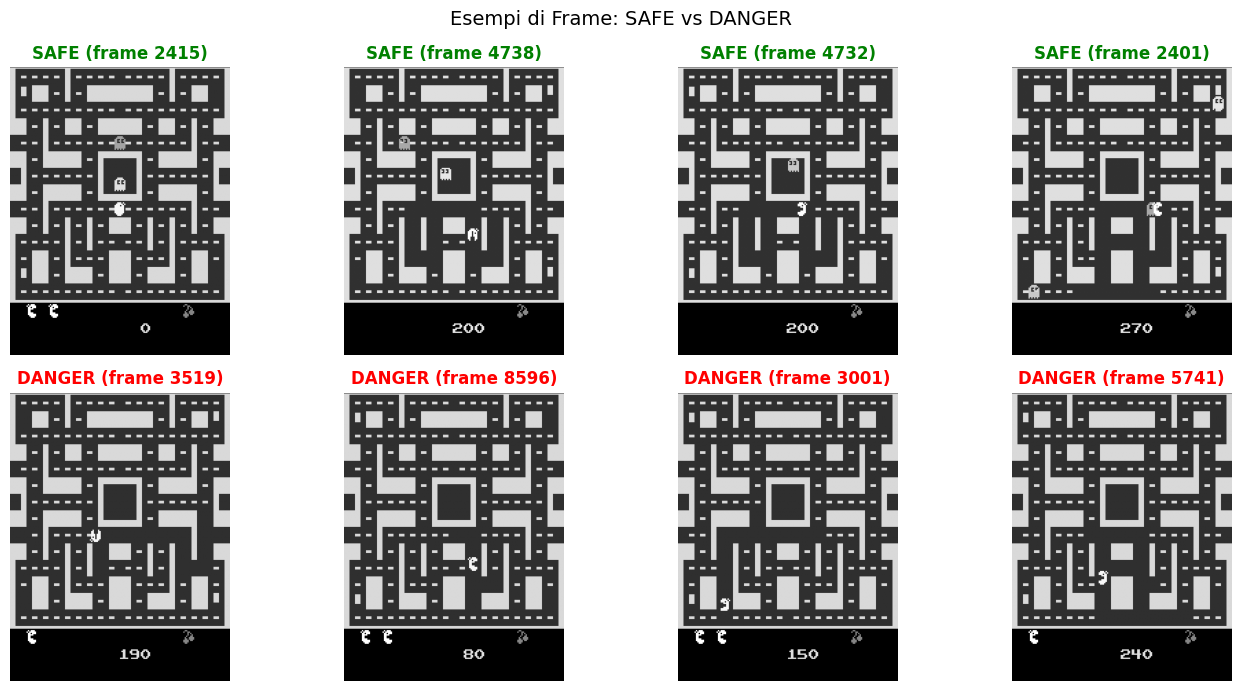

In [8]:
# Visualise representative samples from each class to qualitatively inspect
# the distinction between SAFE and DANGER frames in the dataset.
import matplotlib.pyplot as plt
import numpy as np

safe_indices   = np.where(raw_labels == 0)[0]
danger_indices = np.where(raw_labels == 1)[0]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
np.random.seed(42)

# Top row: randomly sampled SAFE frames.
for i, idx in enumerate(np.random.choice(safe_indices, 4, replace=False)):
    axes[0, i].imshow(raw_frames[idx], cmap='gray')
    axes[0, i].set_title(f'SAFE (frame {idx})', color='green', fontweight='bold')
    axes[0, i].axis('off')

# Bottom row: randomly sampled DANGER frames.
for i, idx in enumerate(np.random.choice(danger_indices, 4, replace=False)):
    axes[1, i].imshow(raw_frames[idx], cmap='gray')
    axes[1, i].set_title(f'DANGER (frame {idx})', color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('Esempi di Frame: SAFE vs DANGER', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Temporal rollout around a SAFE → DANGER transition

Finds the first SAFE→DANGER boundary in the dataset and renders the 16 surrounding frames as a 2×8 grid. Confirms that the 15-frame look-ahead window captures the ghost approach trajectory before the collision occurs, not just the frame of contact.

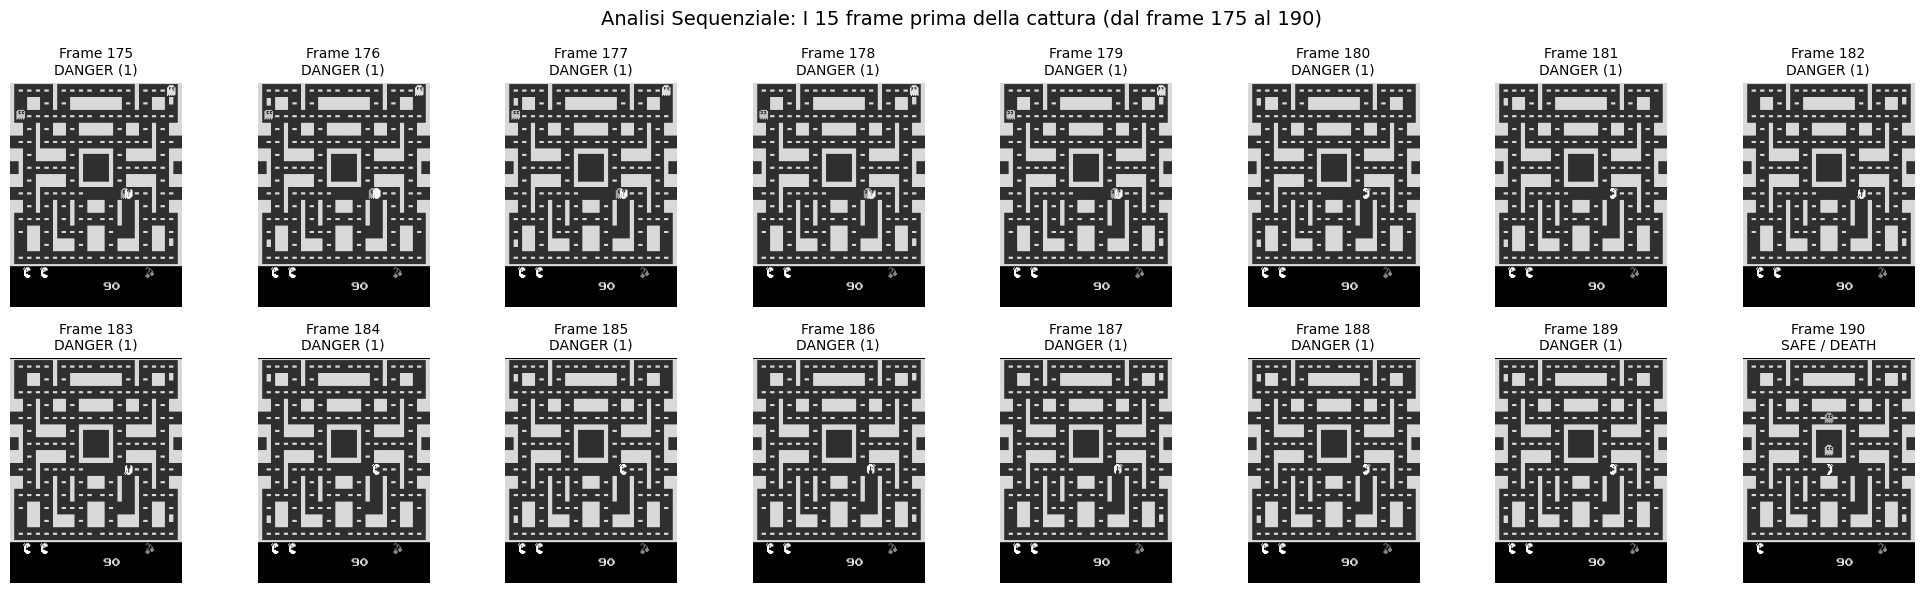

In [9]:
# Perform a sequential analysis by visualising the 16 frames surrounding
# the first SAFE-to-DANGER transition, illustrating how the labelling
# window captures the lead-up to a ghost capture event.
import matplotlib.pyplot as plt
import numpy as np

# Identify all frame indices where the label transitions from SAFE to DANGER.
transitions = np.where((raw_labels[:-1] == 0) & (raw_labels[1:] == 1))[0]

if len(transitions) > 0:
    start_idx = transitions[0] + 1
    num_frames_to_show = 16

    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    fig.suptitle(
        f"Analisi Sequenziale: I 15 frame prima della cattura (dal frame {start_idx} al {start_idx+15})",
        fontsize=14
    )

    for i in range(num_frames_to_show):
        ax  = axes[i // 8, i % 8]
        idx = start_idx + i
        if idx < len(raw_frames):
            ax.imshow(raw_frames[idx], cmap='gray')
            label_text = "DANGER (1)" if raw_labels[idx] == 1 else "SAFE / DEATH"
            ax.set_title(f"Frame {idx}\n{label_text}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Nessuna situazione di pericolo trovata.")

## 10. Pre-processing pipeline: raw RGB → input tensor

Demonstrates the three-step transform applied to every frame before it enters the network:

1. **Crop** `obs[0:170, :, :]` — removes the bottom HUD so the model cannot exploit score/life indicators as shortcuts.
2. **Resize** to 80×80 with anti-aliasing — preserves maze contours while reducing the input footprint for the CNN.
3. **Grayscale** — drops colour redundancy.

Renders a side-by-side comparison of the raw and processed frames.

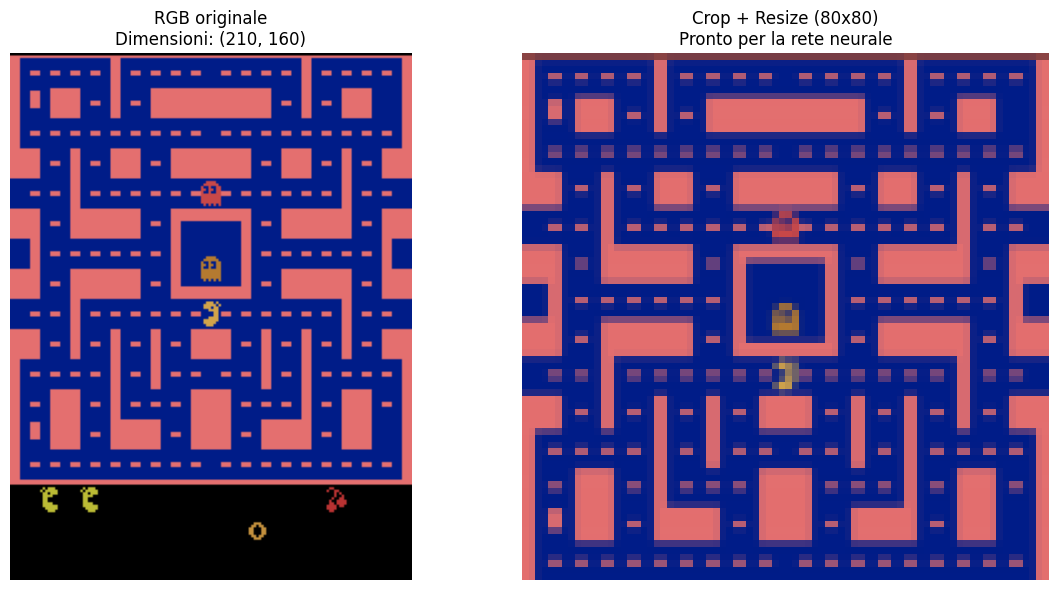

In [10]:
# Demonstrate the full pre-processing pipeline applied to raw environment frames
# before they are fed into the neural network.
import gymnasium as gym
import ale_py
import matplotlib.pyplot as plt
from skimage.transform import resize

gym.register_envs(ale_py)

# Instantiate a temporary RGB environment and advance it for 30 steps
# to obtain a representative non-initial frame.
env_rgb = gym.make("ALE/MsPacman-v5", obs_type="rgb")
obs, info = env_rgb.reset(seed=42)
for _ in range(30):
    action = env_rgb.action_space.sample()
    obs, reward, terminated, truncated, info = env_rgb.step(action)
env_rgb.close()

# Crop the HUD region from the bottom of the frame and resize to 80×80 pixels.
cropped_obs = obs[0:170, :, :]
resized_obs = resize(cropped_obs, (80, 80), anti_aliasing=True)

# Compare the original RGB frame and the pre-processed output side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(obs)
axes[0].set_title(f"RGB originale\nDimensioni: {obs.shape[:2]}")
axes[0].axis('off')
axes[1].imshow(resized_obs)
axes[1].set_title(f"Crop + Resize (80x80)\nPronto per la rete neurale")
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 11. Baseline training (~3 min on T4)

Launches `train_baseline.py` as a subprocess with `checkpoint_dir` overridden to `BASE_DIR`.

Set `SKIP_TRAINING_BASELINE = True` to load pre-trained weights from the `INPUT` path and skip training entirely.

In [11]:
# Train the baseline model via an external script, or skip training and load
# pre-trained weights if they are already available.
import subprocess

SKIP_TRAINING_BASELINE = False  # Set to True to bypass training and use pre-trained weights.

if SKIP_TRAINING_BASELINE and os.path.exists(BASELINE_PATH_INPUT):
    print(f"Skipping training, will load from {BASELINE_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_baseline.py'),
        f'training.checkpoint_dir={BASE_DIR}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Running: python /kaggle/working/pacman-world-model/train_baseline.py training.checkpoint_dir=/kaggle/working



wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: costantini572 (costantini572-sapienza-universit-di-roma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/pacman-world-model/wandb/run-20260528_095503-1owddtvu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Baseline-baseline
wandb: ⭐️ View project at https://wandb.ai/costantini572-sapienza-universit-di-roma/DLPROJECT
wandb: 🚀 View run at https://wandb.ai/costantini572-sapienza-universit-di-roma/DLPROJECT/runs/1owddtvu


Loading cached dataset from data/raw_frames_10k.npz...
Class weights: SAFE=1.0, DANGER=15.29
Training Baseline on cuda...


Epoch [2/10]:   0%|          | 0/250 [00:00<?, ?it/s]

  Epoch 1: tot=1.3125, mse=0.005205, bce=1.2605


...

  Epoch 8: tot=0.2315, mse=0.000381, bce=0.2277


Epoch [10/10]:   0%|          | 0/250 [00:00<?, ?it/s]

  Epoch 9: tot=0.2037, mse=0.000351, bce=0.2002


Epoch [10/10]: 100%|██████████| 250/250 [00:06<00:00, 37.28it/s]
wandb: updating run metadata
wandb: uploading history steps 8-9, summary, console lines 19-23
wandb: 
wandb: Run history:
wandb:        bce █▄▂▂▂▁▁▁▁▁
wandb:      epoch ▁▂▃▃▄▅▆▆▇█
wandb:        mse █▂▁▁▁▁▁▁▁▁
wandb: total_loss █▄▂▂▂▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:        bce 0.22063
wandb:      epoch 10
wandb:        mse 0.00035
wandb: total_loss 0.2241
wandb: 
wandb: 🚀 View run Baseline-baseline at: https://wandb.ai/costantini572-sapienza-universit-di-roma/DLPROJECT/runs/1owddtvu
wandb: ⭐️ View project at: https://wandb.ai/costantini572-sapienza-universit-di-roma/DLPROJECT
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260528_095503-1owddtvu/logs


  Epoch 10: tot=0.2241, mse=0.000347, bce=0.2206
Saved checkpoint to /kaggle/working/baseline_checkpoint.pth

Return code: 0


## 12. Instantiate Baseline and load weights

Initialises `PacmanWorldModel` with `latent_dim=64` and loads the state dict. Prefers a freshly trained checkpoint from `BASELINE_PATH_OUTPUT`; falls back to `BASELINE_PATH_INPUT` if none exists.

Sets `baseline.eval()` — disables dropout and freezes BN statistics for all downstream evaluation.

In [12]:
# Load the baseline model, prioritising a freshly trained checkpoint over
# the pre-trained input weights when both are available.
import torch

baseline = PacmanWorldModel(latent_dim=64).to(device)

ckpt_path = BASELINE_PATH_OUTPUT if os.path.exists(BASELINE_PATH_OUTPUT) else BASELINE_PATH_INPUT

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    baseline.load_state_dict(ckpt['model_state_dict'])
    baseline.eval()
    print(f"Baseline loaded from {ckpt_path}")
else:
    print(f"⚠️ No Baseline checkpoint found. Run training first.")

Baseline loaded from /kaggle/working/baseline_checkpoint.pth


## 13. Training curves

Defines `plot_training_history`: reads the `history` dict from a `.pth` checkpoint and plots all recorded metrics (MSE, accuracy, LR schedule) as a subplot grid.

Applied here to the Baseline — expected: MSE and BCE converging within 10 epochs.

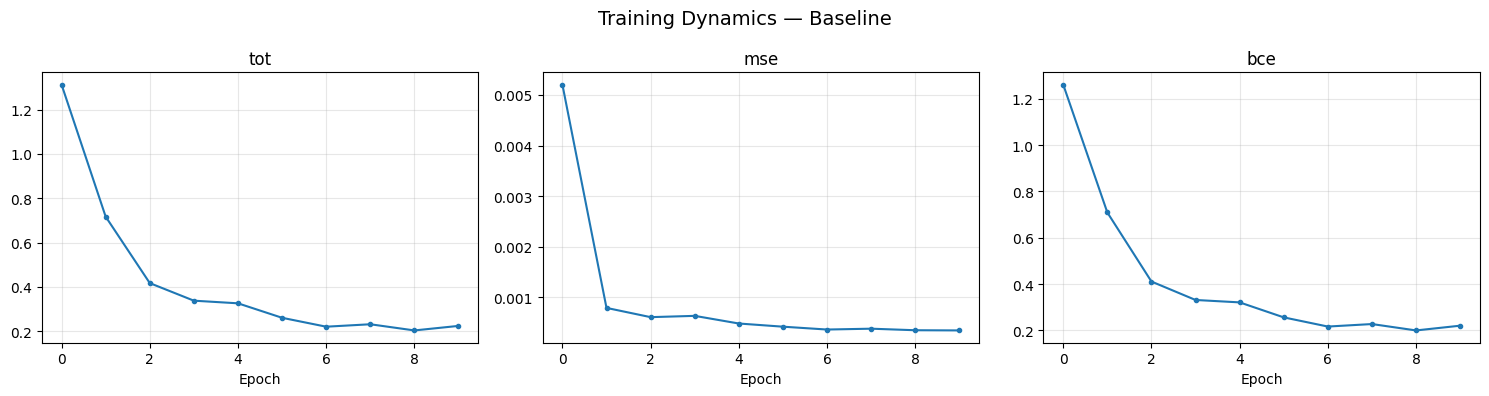

In [13]:
# Utility function to load a checkpoint and plot all recorded training curves.
import matplotlib.pyplot as plt
import torch

def plot_training_history(ckpt_path, title):
    """Load a checkpoint and plot the loss curves stored in its history."""
    if not os.path.exists(ckpt_path):
        print(f"⚠️ Checkpoint not found: {ckpt_path}")
        return

    ckpt    = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    history = ckpt.get('history', {})

    if not history:
        print(f"⚠️ No training history found in {ckpt_path}")
        return

    # Retain only keys whose values are non-empty lists (i.e. per-epoch metrics).
    numeric_keys = [k for k in history.keys() if isinstance(history[k], list) and len(history[k]) > 0]

    if not numeric_keys:
        print("⚠️ No curves to plot.")
        return

    n_plots = len(numeric_keys)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for ax, key in zip(axes, numeric_keys):
        ax.plot(history[key], marker='o', markersize=3)
        ax.set_title(f"{key}")
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot the training dynamics of the baseline model.
baseline_ckpt = BASELINE_PATH_OUTPUT if os.path.exists(BASELINE_PATH_OUTPUT) else BASELINE_PATH_INPUT
plot_training_history(baseline_ckpt, "Training Dynamics — Baseline")

## 14. Qualitative reconstruction check (Baseline)

Runs a forward pass on a test batch and renders a 2×4 grid: original frames on top, reconstructions below.

Expected: maze topology and static walls preserved; dynamic entities (Pac-Man, ghosts) may appear slightly blurred due to the MSE objective averaging over positional uncertainty.

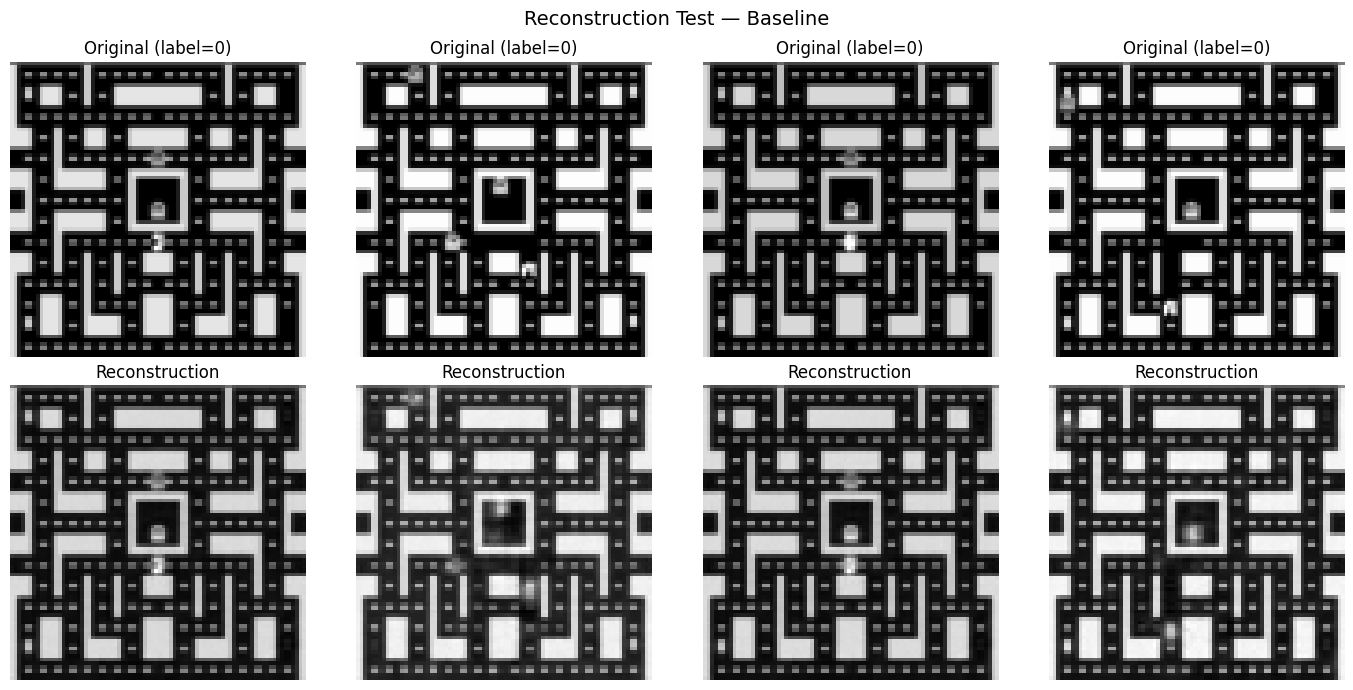

In [14]:
# Build the test data loader for the baseline model evaluation.
_, test_loader_baseline, _ = build_loaders_single(
    raw_frames, raw_labels, batch_size=32, split_seed=42, sampler_seed=42
)

# Retrieve a single test batch and compute reconstructions in inference mode.
sample_batch, sample_labels = next(iter(test_loader_baseline))
sample_batch = sample_batch.to(device)

with torch.no_grad():
    reconstructions, predictions, latents = baseline(sample_batch)

# Visually compare four original frames against their reconstructions.
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(sample_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'Original (label={sample_labels[i].item()})')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1, i].set_title(f'Reconstruction')
    axes[1, i].axis('off')

plt.suptitle('Reconstruction Test — Baseline', fontsize=14)
plt.tight_layout()
plt.show()

## 15. Continuous latent space interpolation (Baseline)

Encodes a SAFE frame from the start of the dataset and a DANGER frame from the end, then decodes 8 linearly interpolated vectors:

$$z_{\text{interp}} = (1 - \alpha)\, z_A + \alpha\, z_B, \quad \alpha \in [0, 1]$$

Expected: smooth cross-fade between states — entities fade out at origin and in at destination rather than translating. This is the characteristic MSE blurring of a continuous bottleneck, contrasted with the discrete VQ-VAE in Section 21.

Frame A (SAFE):   idx 100
Frame B (DANGER): idx 8208
Temporal distance: 8108 steps


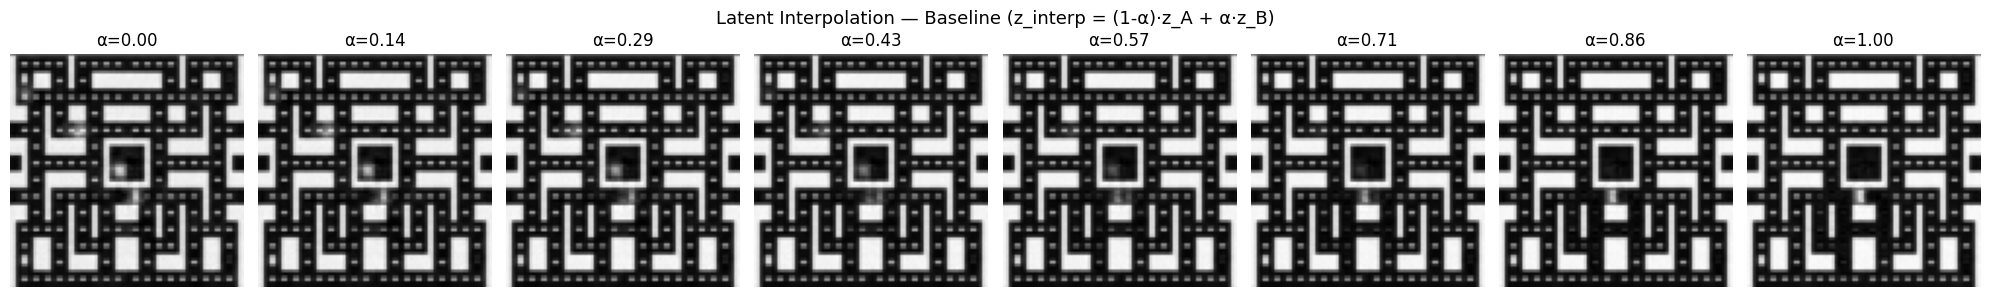

In [15]:
# Perform linear interpolation in the latent space between a SAFE and a DANGER frame
# to qualitatively assess the smoothness and structure of the learned latent representation.
import numpy as np

# Select temporally distant frames to ensure visually distinct endpoints for interpolation.
safe_indices   = np.where(raw_labels == 0)[0]
danger_indices = np.where(raw_labels == 1)[0]
safe_idx   = safe_indices[100]      # SAFE frame sampled near the beginning of the dataset.
danger_idx = danger_indices[-100]   # DANGER frame sampled near the end of the dataset.

print(f"Frame A (SAFE):   idx {safe_idx}")
print(f"Frame B (DANGER): idx {danger_idx}")
print(f"Temporal distance: {danger_idx - safe_idx} steps")

# Apply the standard pre-processing pipeline and move tensors to the target device.
transform = get_transform_pipeline()
img_A = transform(raw_frames[safe_idx][0:170, :]).unsqueeze(0).to(device)
img_B = transform(raw_frames[danger_idx][0:170, :]).unsqueeze(0).to(device)

# Encode both frames and interpolate linearly between their latent vectors.
num_steps = 8
alphas = np.linspace(0, 1, num_steps)
interpolated = []

with torch.no_grad():
    _, _, z_A = baseline(img_A)
    _, _, z_B = baseline(img_B)
    for alpha in alphas:
        z_interp    = (1 - alpha) * z_A + alpha * z_B
        dec_reshaped = baseline.decoder_reshape(z_interp).view(-1, 64, 10, 10)
        img_recon   = baseline.decoder_convs(dec_reshaped)
        interpolated.append(img_recon.detach().cpu())

# Display the decoded frames along the interpolation path.
fig, axes = plt.subplots(1, num_steps, figsize=(20, 3))
for i, (img, alpha) in enumerate(zip(interpolated, alphas)):
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'α={alpha:.2f}')
    axes[i].axis('off')

plt.suptitle('Latent Interpolation — Baseline (z_interp = (1-α)·z_A + α·z_B)', fontsize=13)
plt.tight_layout()
plt.show()

## 16. Classification evaluation (Baseline)

Runs inference over the full test set and reports precision, recall, and F1 for both classes. Renders a confusion matrix heatmap.

The F1 (DANGER) score is the primary diagnostic: a low value signals that the weighted BCE was insufficient to overcome the 94%/6% imbalance. Expected: ~0.60 ± 0.03.

--- Baseline Classification Report ---
              precision    recall  f1-score   support

        SAFE       1.00      0.92      0.96      1871
      DANGER       0.46      0.95      0.62       129

    accuracy                           0.92      2000
   macro avg       0.73      0.94      0.79      2000
weighted avg       0.96      0.92      0.94      2000



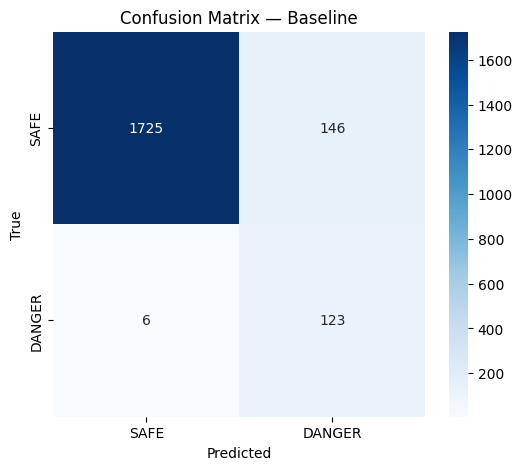

In [16]:
# Evaluate the baseline classifier on the test set and report per-class metrics
# alongside a confusion matrix.
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
baseline.eval()

with torch.no_grad():
    for batch_imgs, batch_lbls in test_loader_baseline:
        batch_imgs = batch_imgs.to(device)
        _, pred, _ = baseline(batch_imgs)
        # Apply a 0.5 decision threshold to convert sigmoid outputs to binary predictions.
        all_preds.extend((pred.squeeze() >= 0.5).long().cpu().numpy())
        all_labels.extend(batch_lbls.numpy())

print("--- Baseline Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['SAFE', 'DANGER']))

# Plot the confusion matrix to visualise false positive and false negative rates.
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['SAFE', 'DANGER'], yticklabels=['SAFE', 'DANGER'])
plt.title('Confusion Matrix — Baseline')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

## 17. VQ-VAE training (~25 min on T4)

Launches `train_vqvae.py` as a subprocess with `checkpoint_dir` overridden to `BASE_DIR`.

Set `SKIP_TRAINING_VQVAE = True` to load pre-trained weights from `VQVAE_PATH_INPUT` and skip training.

In [17]:
# Train the VQ-VAE model via an external script, or skip training and load
# pre-trained weights if they are already available.
SKIP_TRAINING_VQVAE = True  # Set to False to retrain from scratch.

if SKIP_TRAINING_VQVAE and os.path.exists(VQVAE_PATH_INPUT):
    print(f"Skipping training, will load from {VQVAE_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_vqvae.py'),
        f'training.checkpoint_dir={BASE_DIR}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping training, will load from /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/vqvae_checkpoint.pth


## 18. Instantiate VQ-VAE and codebook utilisation check

Initialises `VQVAE` with `num_embeddings=128`, `embedding_dim=64`, `commitment_cost=1.0` and loads weights via the same output→input fallback as Section 12.

Counts unique token indices assigned across the test set. Expected: all 128 codewords active — confirmed by EMA update stability from epoch 6 onward. A significantly lower count indicates codebook collapse.

In [18]:
# Load the VQ-VAE checkpoint, prioritising a freshly trained output over pre-trained input weights.
vqvae = VQVAE(num_embeddings=128, embedding_dim=64, commitment_cost=1.0).to(device)
ckpt_path = VQVAE_PATH_OUTPUT if os.path.exists(VQVAE_PATH_OUTPUT) else VQVAE_PATH_INPUT

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    vqvae.load_state_dict(ckpt['model_state_dict'])
    vqvae.eval()
    print(f"VQ-VAE loaded from {ckpt_path}")
else:
    print("⚠️ No VQ-VAE checkpoint found.")

# Measure codebook utilisation by counting the number of distinct tokens
# assigned across the test set via nearest-neighbour lookup in embedding space.
all_indices = []
with torch.no_grad():
    for batch_images, _ in test_loader_baseline:
        z      = vqvae.encoder(batch_images.to(device))
        z_flat = z.permute(0, 2, 3, 1).contiguous().view(-1, 64)
        # Compute squared Euclidean distances to all codebook embeddings.
        dists = (
            torch.sum(z_flat**2, dim=1, keepdim=True)
            + torch.sum(vqvae.vq.embeddings**2, dim=1)
            - 2 * torch.matmul(z_flat, vqvae.vq.embeddings.t())
        )
        indices = torch.argmin(dists, dim=1)
        all_indices.append(indices.cpu())

active = len(torch.unique(torch.cat(all_indices)))
print(f"Active tokens: {active}/128")

VQ-VAE loaded from /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/vqvae_checkpoint.pth
Active tokens: 128/128


## 19. VQ-VAE training curves

Applies `plot_training_history` to the VQ-VAE checkpoint. Monitor the commitment loss alongside MSE: both should converge smoothly within 50 epochs without diverging, confirming that the EMA codebook update prevented index collapse.

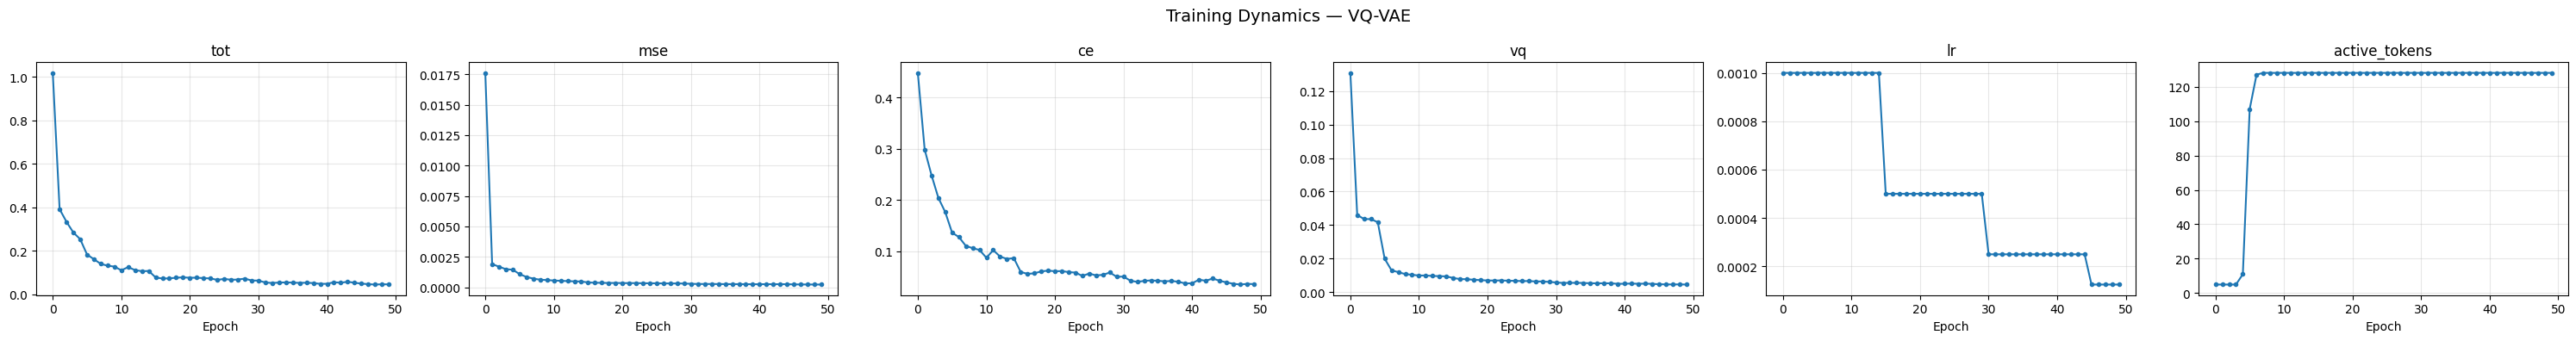

In [19]:
# Plot the VQ-VAE training curves using the previously defined utility function.
vqvae_ckpt = VQVAE_PATH_OUTPUT if os.path.exists(VQVAE_PATH_OUTPUT) else VQVAE_PATH_INPUT
plot_training_history(vqvae_ckpt, "Training Dynamics — VQ-VAE")

## 20. Classification evaluation (VQ-VAE)

Same evaluation protocol as Section 16. VQ-VAE outputs raw logits — predictions are extracted via `argmax(dim=1)` rather than sigmoid thresholding.

Expected: F1 (DANGER) ~0.76 ± 0.01, a +0.16 gain over the Baseline, confirming that discrete codebook representations are more discriminative for the imbalanced minority class.

In [20]:
# Evaluate the VQ-VAE classifier head on the test set and report per-class metrics.
all_preds, all_labels = [], []
vqvae.eval()

with torch.no_grad():
    for batch_imgs, batch_lbls in test_loader_baseline:
        batch_imgs = batch_imgs.to(device)
        # Extract class logits from the VQ-VAE classification head.
        _, _, logits = vqvae(batch_imgs)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_lbls.numpy())

print("--- VQ-VAE Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['SAFE', 'DANGER']))

--- VQ-VAE Classification Report ---
              precision    recall  f1-score   support

        SAFE       1.00      0.96      0.98      1871
      DANGER       0.64      0.95      0.76       129

    accuracy                           0.96      2000
   macro avg       0.82      0.95      0.87      2000
weighted avg       0.97      0.96      0.96      2000



## 21. Discrete latent space interpolation (VQ-VAE)

Replicates the interpolation experiment from Section 15 on the VQ-VAE. Intermediate vectors are computed with the same Lerp formula, then re-quantised through `vqvae.vq` (nearest-codeword lookup in L₂).

Expected: abrupt step-wise transitions rather than smooth cross-fades — each α shift snaps to the nearest discrete token, producing sharp jumps between valid configurations. Contrast with the ghosting effect observed in Section 15.

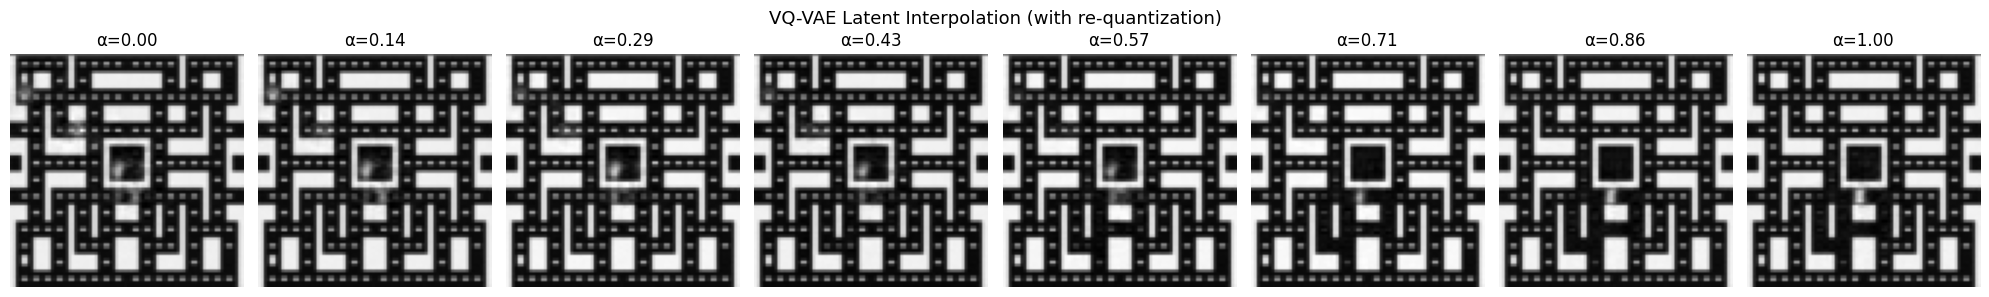

In [21]:
# Perform latent space interpolation with the VQ-VAE between the same SAFE and DANGER
# frames used previously. Each interpolated latent vector is re-quantised through
# the codebook before decoding, reflecting the discrete nature of the VQ representation.
img_A = transform(raw_frames[safe_idx][0:170, :]).unsqueeze(0).to(device)
img_B = transform(raw_frames[danger_idx][0:170, :]).unsqueeze(0).to(device)

interpolated_vq = []
with torch.no_grad():
    z_A = vqvae.encoder(img_A)
    z_B = vqvae.encoder(img_B)
    for alpha in alphas:
        # Linearly interpolate in the continuous encoder output space,
        # then snap to the nearest codebook entry via vector quantisation.
        z_interp  = (1 - alpha) * z_A + alpha * z_B
        q_interp, _ = vqvae.vq(z_interp)
        img_recon = vqvae.decoder(q_interp)
        interpolated_vq.append(img_recon.detach().cpu())

# Display decoded frames along the interpolation path.
fig, axes = plt.subplots(1, num_steps, figsize=(20, 3))
for i, (img, alpha) in enumerate(zip(interpolated_vq, alphas)):
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'α={alpha:.2f}')
    axes[i].axis('off')

plt.suptitle('VQ-VAE Latent Interpolation (with re-quantization)', fontsize=13)
plt.tight_layout()
plt.show()

## 22. Temporal Transformer Classifier training (~10 min on T4)

Launches `train_transformer.py` as a subprocess. The VQ-VAE checkpoint path is injected via `model.training.vqvae_checkpoint=...` — the Transformer uses the frozen VQ-VAE encoder to tokenise input frames before temporal modelling.

Set `SKIP_TRAINING_TRANSFORMER = True` to load pre-trained weights from `CLASSIFIER_PATH_INPUT` and skip training.

In [22]:
# Train the Temporal Transformer Classifier on VQ-VAE token sequences,
# or skip training and load pre-trained weights if available.
SKIP_TRAINING_TRANSFORMER = True  # Set to False to retrain from scratch.

if SKIP_TRAINING_TRANSFORMER and os.path.exists(CLASSIFIER_PATH_INPUT):
    print(f"Skipping, will load from {CLASSIFIER_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_transformer.py'),
        f'training.checkpoint_dir={BASE_DIR}',
        # Pass the VQ-VAE checkpoint so the Transformer can encode input sequences.
        f'model.training.vqvae_checkpoint={VQVAE_PATH_OUTPUT}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping, will load from /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/transformer_classifier_checkpoint.pth


## 23. Temporal Transformer evaluation

Instantiates `TemporalTransformerClassifier` with the frozen VQ-VAE encoder and `vq` modules embedded. Sequences of shape `[B, 8, C, H, W]` are built by `build_loaders_sequence`; the label is taken from the final frame of each window.

Expected: F1 (DANGER) ~0.87 ± 0.06 — the +0.11 gain over the static VQ-VAE (Section 20) quantifies the contribution of 8-frame temporal context to non-Markovian danger prediction.

In [23]:
# Instantiate the Temporal Transformer Classifier, reusing the frozen VQ-VAE
# encoder and quantiser as a fixed tokenisation front-end.
transformer_classifier = TemporalTransformerClassifier(
    vqvae_encoder=vqvae.encoder, vq_module=vqvae.vq,
    seq_len=8, d_model=128, nhead=4, num_layers=4, dropout=0.1
).to(device)

# Load the classifier checkpoint, prioritising a freshly trained output.
ckpt_path = CLASSIFIER_PATH_OUTPUT if os.path.exists(CLASSIFIER_PATH_OUTPUT) else CLASSIFIER_PATH_INPUT
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    transformer_classifier.load_state_dict(ckpt['model_state_dict'])
    transformer_classifier.eval()
    print(f"Loaded from {ckpt_path}")

# Build the sequential test loader, grouping frames into overlapping windows of length 8.
_, _, test_seq_loader, _ = build_loaders_sequence(
    raw_frames, raw_labels, seq_len=8, batch_size=16,
    split_seed=42, sampler_seed=42
)

# Run inference over the full test set and collect predictions.
all_preds, all_labels = [], []
with torch.no_grad():
    for batch_seqs, batch_lbls in test_seq_loader:
        batch_seqs = batch_seqs.to(device)
        logits = transformer_classifier(batch_seqs)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_lbls.numpy())

print("--- Temporal Transformer Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['SAFE', 'DANGER']))

Loaded from /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/transformer_classifier_checkpoint.pth
--- Temporal Transformer Classification Report ---
              precision    recall  f1-score   support

        SAFE       1.00      0.98      0.99      1886
      DANGER       0.75      0.93      0.83       113

    accuracy                           0.98      1999
   macro avg       0.87      0.96      0.91      1999
weighted avg       0.98      0.98      0.98      1999



## 24. Inference latency benchmark (pre-pruning)

Measures throughput and latency of the Temporal Transformer on 8-frame sequences. A warm-up pass runs first to initialise CUDA kernels; `torch.cuda.synchronize()` brackets the timed block to avoid asynchronous CPU underestimation.

Expected: ~1.48 ms/seq (675 seq/s) on T4 — a 10× safety margin against the 60 FPS real-time constraint.

In [24]:
# Benchmark inference latency and throughput of the Temporal Transformer
# prior to any pruning or compression, establishing a pre-optimisation baseline.
import time

print("="*60)
print("  BENCHMARK INFERENZA TEMPORAL TRANSFORMER")
print("="*60)

transformer_classifier.eval()
total_samples = 0

with torch.no_grad():
    # Warm-up pass to initialise CUDA kernels and avoid cold-start bias.
    for batch_seqs, _ in test_seq_loader:
        batch_seqs = batch_seqs.to(device)
        _ = transformer_classifier(batch_seqs)
        break

    # Synchronise CUDA before timing to ensure accurate wall-clock measurement.
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.time()
    for batch_seqs, _ in test_seq_loader:
        batch_seqs = batch_seqs.to(device)
        _ = transformer_classifier(batch_seqs)
        total_samples += batch_seqs.size(0)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    total_time = time.time() - start

throughput_transformer_pre = total_samples / total_time
latency_transformer_pre    = (total_time / total_samples) * 1000
acc_transformer_pre        = 100. * sum(1 for p, l in zip(all_preds, all_labels) if p == l) / len(all_labels)

print(f"Accuracy:    {acc_transformer_pre:.2f}%")
print(f"Time:        {total_time:.2f} sec ({total_samples} sequences)")
print(f"Throughput:  {throughput_transformer_pre:.1f} seq/sec")
print(f"Latency:     {latency_transformer_pre:.2f} ms/seq")

  BENCHMARK INFERENZA TEMPORAL TRANSFORMER
Accuracy:    97.85%
Time:        2.90 sec (1999 sequences)
Throughput:  690.1 seq/sec
Latency:     1.45 ms/seq


## 25. Temporal Transformer training curves

Applies `plot_training_history` to the Transformer checkpoint. Expected: cross-entropy loss converging within 10 epochs with no significant train/test gap, confirming that 8-frame sequences do not overfit on the 10k dataset.

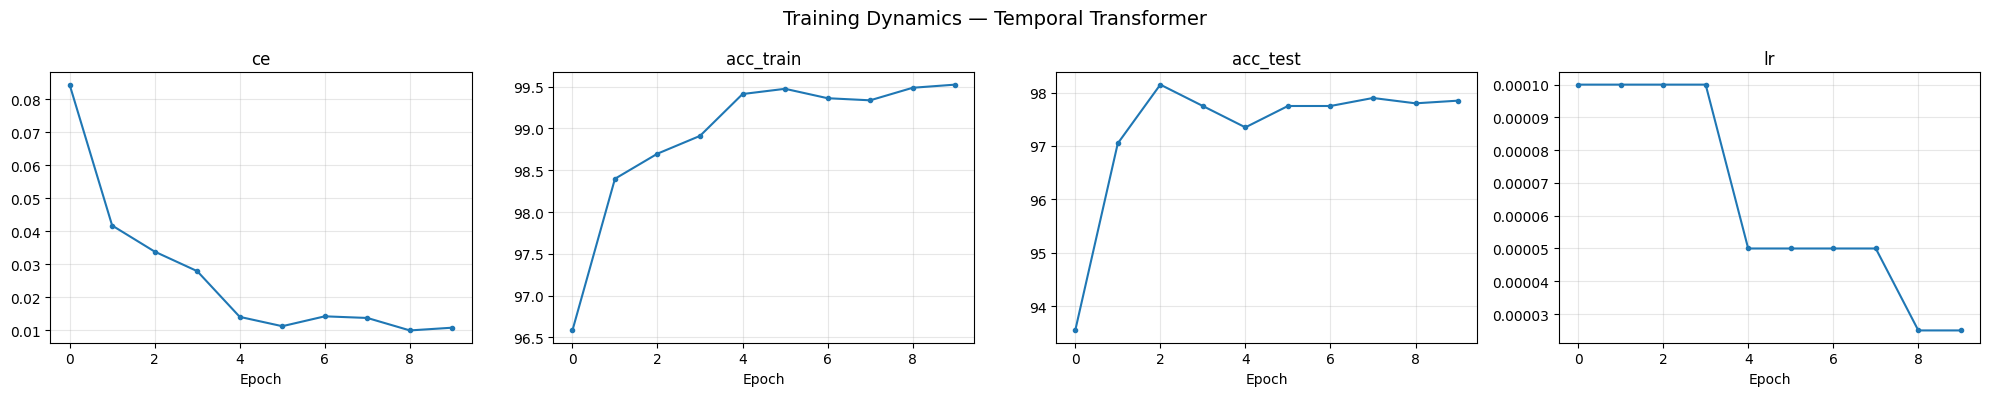

In [25]:
# Plot the Temporal Transformer Classifier training curves.
cls_ckpt = CLASSIFIER_PATH_OUTPUT if os.path.exists(CLASSIFIER_PATH_OUTPUT) else CLASSIFIER_PATH_INPUT
plot_training_history(cls_ckpt, "Training Dynamics — Temporal Transformer")

## 26. Comparative accuracy summary

Aggregates test accuracy for all three classifiers on the same test set. `get_accuracy` handles the output-layer difference between Baseline (sigmoid + 0.5 threshold) and VQ-VAE (argmax); the Transformer is evaluated on `test_seq_loader`.

Renders a bar chart with two readable deltas:
- **Baseline → VQ-VAE**: gain from discrete codebook over continuous bottleneck (+4.23 pp).
- **VQ-VAE → Transformer**: gain from 8-frame temporal context over single-frame (+2.07 pp).

Baseline  (continuous, 1 frame):   92.40%
VQ-VAE    (discrete,   1 frame):   96.00%
Temporal Transformer   (8 frames): 97.85%


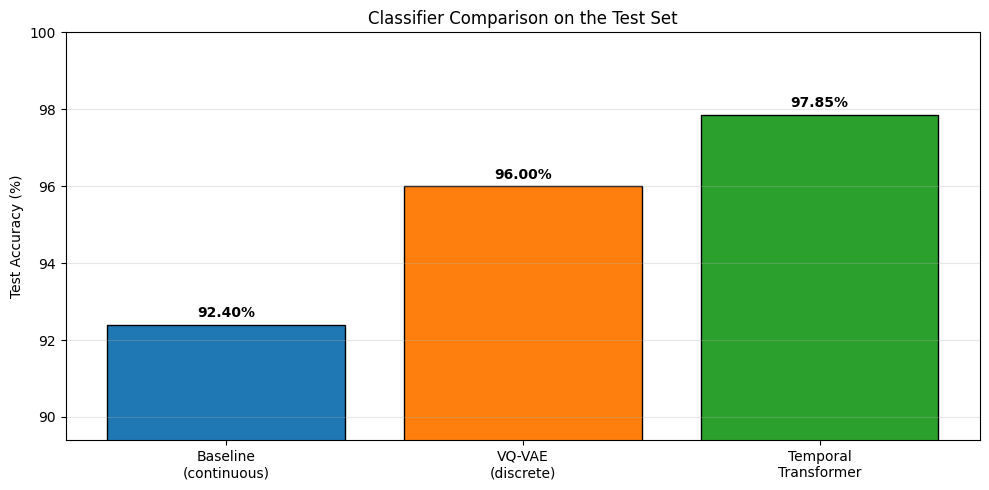

In [26]:
# Utility function to compute classification accuracy for single-frame models.
def get_accuracy(model, loader, is_baseline=False):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.to(device)
            # Baseline uses a sigmoid output; VQ-VAE uses a softmax classification head.
            if is_baseline:
                _, pred, _ = model(imgs)
                preds = (pred.squeeze() >= 0.5).long()
            else:
                _, _, logits = model(imgs)
                preds = logits.argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return 100. * correct / total

acc_baseline = get_accuracy(baseline, test_loader_baseline, is_baseline=True)
acc_vqvae    = get_accuracy(vqvae,    test_loader_baseline, is_baseline=False)

# Evaluate the Temporal Transformer separately, as it operates on frame sequences.
correct, total = 0, 0
transformer_classifier.eval()
with torch.no_grad():
    for seqs, lbls in test_seq_loader:
        seqs = seqs.to(device)
        lbls = lbls.to(device)
        logits = transformer_classifier(seqs)
        correct += (logits.argmax(dim=1) == lbls).sum().item()
        total   += lbls.size(0)
acc_transformer = 100. * correct / total

print(f"Baseline  (continuous, 1 frame):   {acc_baseline:.2f}%")
print(f"VQ-VAE    (discrete,   1 frame):   {acc_vqvae:.2f}%")
print(f"Temporal Transformer   (8 frames): {acc_transformer:.2f}%")

# Bar chart comparing test accuracy across the three classifiers.
fig, ax = plt.subplots(figsize=(10, 5))
model_names = ['Baseline\n(continuous)', 'VQ-VAE\n(discrete)', 'Temporal\nTransformer']
accs   = [acc_baseline, acc_vqvae, acc_transformer]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars   = ax.bar(model_names, accs, color=colors, edgecolor='black')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Classifier Comparison on the Test Set')
ax.set_ylim([min(accs) - 3, 100])
ax.grid(True, axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 27. Global unstructured L1 pruning (20%) + robustness check

Applies 20% global L1 unstructured pruning to all `Conv2d` layers in the VQ-VAE encoder, then re-evaluates the full Temporal Transformer pipeline zero-shot.

Global (not per-layer) pruning lets the criterion concentrate removals on the most redundant layers: expected sparsity ~23% on the deepest conv, ~2.9% on the first. Expected accuracy drop: Δ = 0.00% — confirming the encoder is over-parameterised and the discrete topological mapping is robust to magnitude-based compression.

In [27]:
# Apply global unstructured L1 pruning to the VQ-VAE encoder's convolutional layers
# and measure the impact on sparsity and downstream classification accuracy.
import torch.nn.utils.prune as prune

acc_pre = acc_transformer
print(f"Accuracy pre-pruning: {acc_pre:.2f}%")

# Collect all Conv2d layers in the VQ-VAE encoder as pruning targets.
modules_to_prune = []
for name, module in vqvae.encoder.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        modules_to_prune.append((module, 'weight'))

# Remove the 20% of weights with the smallest L1 norm across all targeted layers.
prune.global_unstructured(
    modules_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.2,
)

# Make pruning permanent by removing the weight masks and updating the parameters in place.
for module, name in modules_to_prune:
    prune.remove(module, name)

# Report per-layer and global sparsity after pruning.
total_params, total_zeros = 0, 0
for i, (module, _) in enumerate(modules_to_prune):
    n_params  = module.weight.nelement()
    n_zeros   = float(torch.sum(module.weight == 0))
    sparsity  = 100.0 * n_zeros / n_params
    total_params += n_params
    total_zeros  += n_zeros
    print(f"Conv2d[{i}]: {sparsity:.2f}% sparse ({int(n_zeros)}/{n_params})")
print(f"\nGlobal sparsity: {100.0 * total_zeros / total_params:.2f}%")

# Re-evaluate the Temporal Transformer using the pruned VQ-VAE encoder.
correct, total = 0, 0
transformer_classifier.eval()
with torch.no_grad():
    for seqs, lbls in test_seq_loader:
        seqs, lbls = seqs.to(device), lbls.to(device)
        logits = transformer_classifier(seqs)
        correct += (logits.argmax(dim=1) == lbls).sum().item()
        total   += lbls.size(0)
acc_post = 100. * correct / total

print(f"\nAccuracy post-pruning: {acc_post:.2f}%")
print(f"Δ accuracy: {acc_post - acc_pre:+.2f}%")
if acc_post >= acc_pre - 1.0:
    print("✅ 20% pruning applied with no significant accuracy degradation.")

Accuracy pre-pruning: 97.85%
Conv2d[0]: 2.93% sparse (15/512)
Conv2d[1]: 9.47% sparse (3102/32768)
Conv2d[2]: 23.00% sparse (30141/131072)
Conv2d[3]: 15.27% sparse (1251/8192)

Global sparsity: 20.00%

Accuracy post-pruning: 97.85%
Δ accuracy: +0.00%
✅ 20% pruning applied with no significant accuracy degradation.


## 28. Token-level Prior training (~45 min on T4)

Launches `train_token_prior.py` as a subprocess. The unpruned VQ-VAE checkpoint (`VQVAE_PATH_OUTPUT`) is injected explicitly — pruning shifts continuous feature maps and can alter nearest-codeword assignments, so the Prior must be trained on the original, uncompressed tokeniser to avoid codebook distribution shift.

Set `SKIP_TRAINING_TOKEN_PRIOR = True` to load pre-trained weights from `PRIOR_PATH_INPUT` and skip training.

In [28]:
# Train the token-level Transformer Prior on VQ-VAE discrete token sequences,
# or skip training and load pre-trained weights if available.
# Note: the unpruned VQ-VAE must be used here to ensure codebook index consistency.
SKIP_TRAINING_TOKEN_PRIOR = True  # Set to False to retrain from scratch.

if SKIP_TRAINING_TOKEN_PRIOR and os.path.exists(PRIOR_PATH_INPUT):
    print(f"Skipping, will load from {PRIOR_PATH_INPUT}")
else:
    # Reload the original (unpruned) VQ-VAE to guarantee consistent token indices
    # between the prior training and the codebook embedding space.
    vqvae_for_prior = VQVAE(num_embeddings=128, embedding_dim=64, commitment_cost=1.0).to(device)
    ckpt = torch.load(VQVAE_PATH_OUTPUT, map_location=device, weights_only=False)
    vqvae_for_prior.load_state_dict(ckpt['model_state_dict'])
    vqvae_for_prior.eval()
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_token_prior.py'),
        f'training.checkpoint_dir={BASE_DIR}',
        f'model.training.vqvae_checkpoint={VQVAE_PATH_OUTPUT}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping, will load from /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/transformer_prior_checkpoint.pth


## 29. Instantiate Token Prior and restore unpruned VQ-VAE

Loads `TransformerPrior` with `num_embeddings=128` via the standard output→input fallback.

Re-instantiates a separate `vqvae_original` from the unpruned checkpoint for all downstream generative rollouts. The pruned `vqvae` from Section 27 is retained only for classification — generative tasks require the exact tokeniser the Prior was trained on.

In [29]:
# Load the Token-level Transformer Prior, which models the distribution
# over discrete VQ-VAE token sequences for autoregressive generation.
transformer_prior = TransformerPrior(num_embeddings=128).to(device)
ckpt_path = PRIOR_PATH_OUTPUT if os.path.exists(PRIOR_PATH_OUTPUT) else PRIOR_PATH_INPUT

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    transformer_prior.load_state_dict(ckpt['model_state_dict'])
    transformer_prior.eval()
    print(f"Token Prior loaded from {ckpt_path}")
else:
    print(f"⚠️ Token Prior checkpoint not found!")

# Reload the original unpruned VQ-VAE to ensure codebook consistency during generation.
vqvae_original = VQVAE(num_embeddings=128, embedding_dim=64, commitment_cost=1.0).to(device)
vqvae_ckpt_path = VQVAE_PATH_OUTPUT if os.path.exists(VQVAE_PATH_OUTPUT) else VQVAE_PATH_INPUT

if os.path.exists(vqvae_ckpt_path):
    ckpt = torch.load(vqvae_ckpt_path, map_location=device, weights_only=False)
    vqvae_original.load_state_dict(ckpt['model_state_dict'])
    vqvae_original.eval()
    print(f"Original VQ-VAE reloaded from {vqvae_ckpt_path}")
else:
    print(f"⚠️ VQ-VAE checkpoint not found!")

Token Prior loaded from /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/transformer_prior_checkpoint.pth
Original VQ-VAE reloaded from /kaggle/input/models/leonardocostantini02/modeels/pytorch/default/1/vqvae_checkpoint.pth


## 30. Autoregressive token-level rollout (world simulation)

Seeds the Prior with 8 real frames (800 tokens) from the test set, then generates new frames token-by-token. Each new frame requires 100 sequential forward passes over a sliding 800-token context window.

Sampling uses temperature T=0.9 and top-k (k=64) to suppress improbable tokens without collapsing to deterministic argmax. Generated tokens are looked up in `vqvae_original.vq.embeddings`, reshaped to 10×10×64, and decoded to pixels.

Ground-truth context frames are annotated in blue, hallucinated frames in red. Expected: locally coherent structures in the first 1–2 generated frames; geometric drift and categorical noise accumulate after ~200 autoregressive steps due to exposure bias.

Generating 5 frames token-by-token...


100%|██████████| 5/5 [00:02<00:00,  1.87it/s]


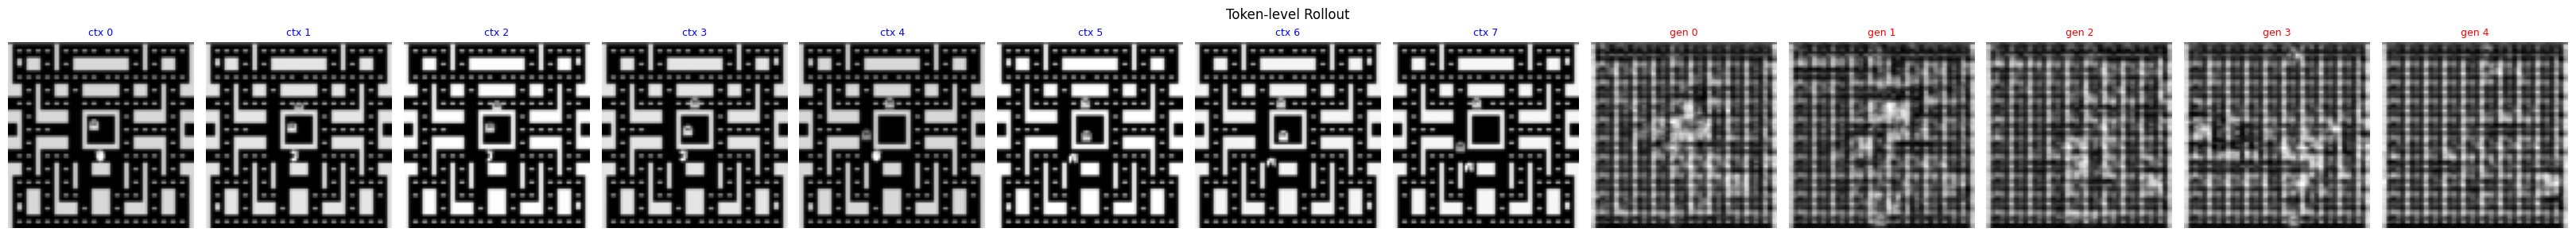

In [30]:
# Autoregressively generate new frames at the token level using the Transformer Prior.
# Context frames are first encoded into discrete VQ-VAE token sequences; the Prior
# then extends the sequence one token at a time, and each generated token map is
# decoded back to pixel space via the VQ-VAE decoder.
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

TOKENS_PER_FRAME  = 100          # Spatial token grid: 10×10 per frame.
SEQ_LEN_TRAIN     = 8            # Number of context frames used during training.
TOTAL_CTX_TOKENS  = SEQ_LEN_TRAIN * TOKENS_PER_FRAME

def sample_with_temperature(logits, temperature=1.0, top_k=64):
    """Sample the next token using temperature scaling and top-k filtering."""
    logits = logits / temperature
    top_k  = min(top_k, logits.shape[-1])
    v, ix  = torch.topk(logits, top_k)
    probs  = F.softmax(v, dim=-1)
    next_token = torch.multinomial(probs, num_samples=1)
    return torch.gather(ix, -1, next_token)

num_frames_to_generate = 5

# Encode the context frames into a flat sequence of discrete codebook indices.
sample_seqs, _ = next(iter(test_seq_loader))
sample_seqs     = sample_seqs.to(device)
context_frames  = sample_seqs[0:1, :SEQ_LEN_TRAIN]
B, S, C, H, W   = context_frames.shape

with torch.no_grad():
    ctx_flat    = context_frames.view(B * S, C, H, W)
    z_ctx       = vqvae_original.encoder(ctx_flat)
    z_flat_ctx  = z_ctx.permute(0, 2, 3, 1).contiguous().view(-1, 64)
    # Assign each spatial feature vector to its nearest codebook entry.
    dists = (
        torch.sum(z_flat_ctx**2, dim=1, keepdim=True)
        + torch.sum(vqvae_original.vq.embeddings**2, dim=1)
        - 2 * torch.matmul(z_flat_ctx, vqvae_original.vq.embeddings.t())
    )
    all_ctx_indices = torch.argmin(dists, dim=1)
    current_indices = all_ctx_indices.view(1, TOTAL_CTX_TOKENS)
    generated_frames = [context_frames[0, f].cpu().squeeze() for f in range(S)]

    print(f"Generating {num_frames_to_generate} frames token-by-token...")
    for f in tqdm(range(num_frames_to_generate)):
        # Extend the token sequence one position at a time for each spatial token.
        for t in range(TOKENS_PER_FRAME):
            transformer_in = current_indices[:, -TOTAL_CTX_TOKENS:]
            logits         = transformer_prior(transformer_in)
            next_tok       = sample_with_temperature(logits[0, -1, :], temperature=0.9, top_k=64)
            current_indices = torch.cat([current_indices, next_tok.view(1, 1)], dim=1)
        # Decode the newly generated token map back to pixel space.
        frame_tokens = current_indices[0, -TOKENS_PER_FRAME:]
        encodings    = F.one_hot(frame_tokens, 128).float()
        q_vec        = torch.matmul(encodings, vqvae_original.vq.embeddings)
        q_spatial    = q_vec.view(1, 10, 10, 64).permute(0, 3, 1, 2).contiguous()
        gen_img      = vqvae_original.decoder(q_spatial).detach().cpu().squeeze()
        generated_frames.append(gen_img)

# Display context frames (blue) alongside generated frames (red).
total = len(generated_frames)
fig, axes = plt.subplots(1, total, figsize=(2.5 * total, 3))
for i, img in enumerate(generated_frames):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    if i < S:
        axes[i].set_title(f'ctx {i}',   color='blue', fontsize=9)
    else:
        axes[i].set_title(f'gen {i-S}', color='red',  fontsize=9)

plt.suptitle('Token-level Rollout', fontsize=12)
plt.tight_layout()
plt.show()

## 31. Export token-level rollout as GIF

Converts decoder outputs to uint8 via min-max normalisation (ε=1e-8 prevents division by zero on uniform frames) and assembles frames into an animated GIF at 400 ms/frame.

In [31]:
# Convert the generated frame tensors to uint8 PIL images and save them as an animated GIF.
from PIL import Image
import numpy as np

print("Creating token-level GIF...")
gif_frames_pil = []
for img_tensor in generated_frames:
    img_np = img_tensor.numpy()
    # Normalise pixel values to [0, 255] before conversion.
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8) * 255.0
    gif_frames_pil.append(Image.fromarray(img_np.astype(np.uint8)))

gif_frames_pil[0].save(
    GIF_OUTPUT_PATH, save_all=True,
    append_images=gif_frames_pil[1:], duration=400, loop=0
)
print(f"✅ GIF saved to: {GIF_OUTPUT_PATH}")

Creating token-level GIF...
✅ GIF saved to: /kaggle/working/pacman_dream.gif


## 32. Token Prior training curves

Applies `plot_training_history` to the Token Prior checkpoint. Expected: cross-entropy loss decreasing steadily over 50 epochs; scheduled sampling ramp (epochs 5→30) should visibly stabilise the loss curve relative to the first pure teacher-forcing phase.

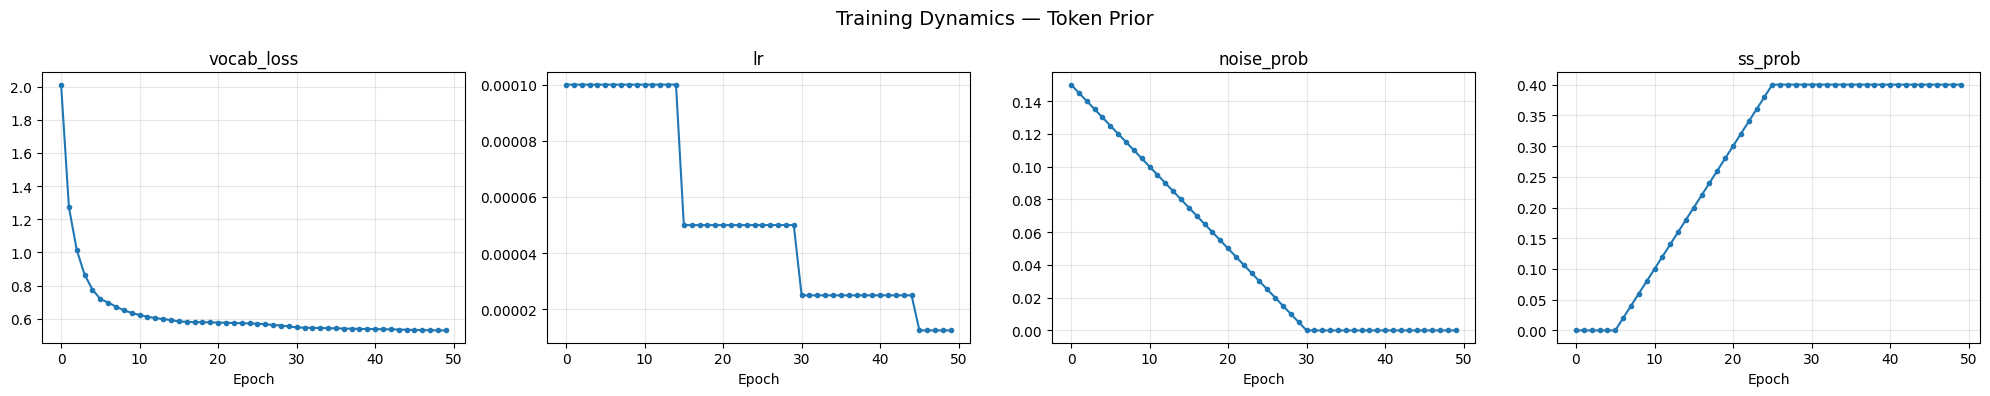

In [32]:
# Plot Token Prior history
tp_ckpt = PRIOR_PATH_OUTPUT if os.path.exists(PRIOR_PATH_OUTPUT) else PRIOR_PATH_INPUT
plot_training_history(tp_ckpt, "Training Dynamics — Token Prior")

## 33. 50k-frame dataset acquisition

Scales the data pipeline from 10k to 50k frames for training the generative priors. Copies the cached `.npz` from `DATASET_50K_INPUT` if available; otherwise collects frames via random policy with the same `danger_window=15` labelling as Section 7.

In [33]:
# Load the 50k-frame dataset from a local cache or copy it from the pre-collected input path.
DATASET_50K_PATH = os.path.join(DATA_DIR, 'raw_frames_50k.npz')

if not os.path.exists(DATASET_50K_PATH) and os.path.exists(DATASET_50K_INPUT):
    print(f"Copying cached 50k dataset from {DATASET_50K_INPUT}...")
    import shutil
    shutil.copy(DATASET_50K_INPUT, DATASET_50K_PATH)

raw_frames_50k, raw_labels_50k = load_or_collect(
    DATASET_50K_PATH, num_frames=50000, danger_window=15, seed=42
)

# Report class distribution of the larger dataset.
n_safe   = int((raw_labels_50k == 0).sum())
n_danger = int((raw_labels_50k == 1).sum())
print(f"\nDataset 50k: SAFE={n_safe}, DANGER={n_danger}")

  Collected 5000/50000 frames...
  Collected 10000/50000 frames...
  Collected 15000/50000 frames...
  Collected 20000/50000 frames...
  Collected 25000/50000 frames...
  Collected 30000/50000 frames...
  Collected 35000/50000 frames...
  Collected 40000/50000 frames...
  Collected 45000/50000 frames...
Saving cache to /kaggle/working/pacman-world-model/data/raw_frames_50k.npz...

Dataset 50k: SAFE=46792, DANGER=3208


## 34. Frame-level Prior training (~30 min on T4)

Launches `train_frame_prior.py` with two overrides: `dataset.cache_path=DATASET_50K_PATH` (50k corpus required for frame-level dynamics) and the unpruned VQ-VAE checkpoint, for the same codebook consistency reason as Section 28.

Set `SKIP_TRAINING_FRAME_PRIOR = True` to load pre-trained weights from `FRAME_PRIOR_PATH_INPUT` and skip training.

In [34]:
# Train the Frame-level Prior on the 50k-frame dataset, or skip and load
# pre-trained weights if available. This model operates at the frame level
# rather than the token level, predicting entire frame embeddings autoregressively.
SKIP_TRAINING_FRAME_PRIOR = True  # Set to False to retrain from scratch.

if SKIP_TRAINING_FRAME_PRIOR and os.path.exists(FRAME_PRIOR_PATH_INPUT):
    print(f"Skipping, will load from {FRAME_PRIOR_PATH_INPUT}")
else:
    cmd = [
        'python', os.path.join(REPO_DIR, 'train_frame_prior.py'),
        'dataset=pacman_50k',
        f'training.checkpoint_dir={BASE_DIR}',
        f'model.training.vqvae_checkpoint={VQVAE_PATH_OUTPUT}',
        f'dataset.cache_path={DATASET_50K_PATH}',
    ]
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, cwd=REPO_DIR)
    print(f"\nReturn code: {result.returncode}")

Skipping, will load from /kaggle/input/models/leonardocostantini02/modeels2/pytorch/default/1/frame_prior_checkpoint.pth


## 35. Autoregressive frame-level rollout

Encodes 8 context frames into latent tensors of shape `(B, 8, 64, 10, 10)`. At each step the Frame Prior predicts the full next latent in a single forward pass — no token-by-token loop. The predicted latent is quantised, decoded to pixels, then appended to the rolling history buffer (oldest frame dropped).

Context frames are annotated in blue, generated frames in green. Expected: maze structure preserved for 15+ steps; moving entities (Pac-Man, ghosts) fade progressively due to MSE regression-to-the-mean. Contrast with the token-level rollout (Section 30): better geometric coherence, worse entity identity.

Frame Prior loaded from /kaggle/input/models/leonardocostantini02/modeels2/pytorch/default/1/frame_prior_checkpoint.pth
Generating 15 frames frame-by-frame...


100%|██████████| 15/15 [00:00<00:00, 258.71it/s]


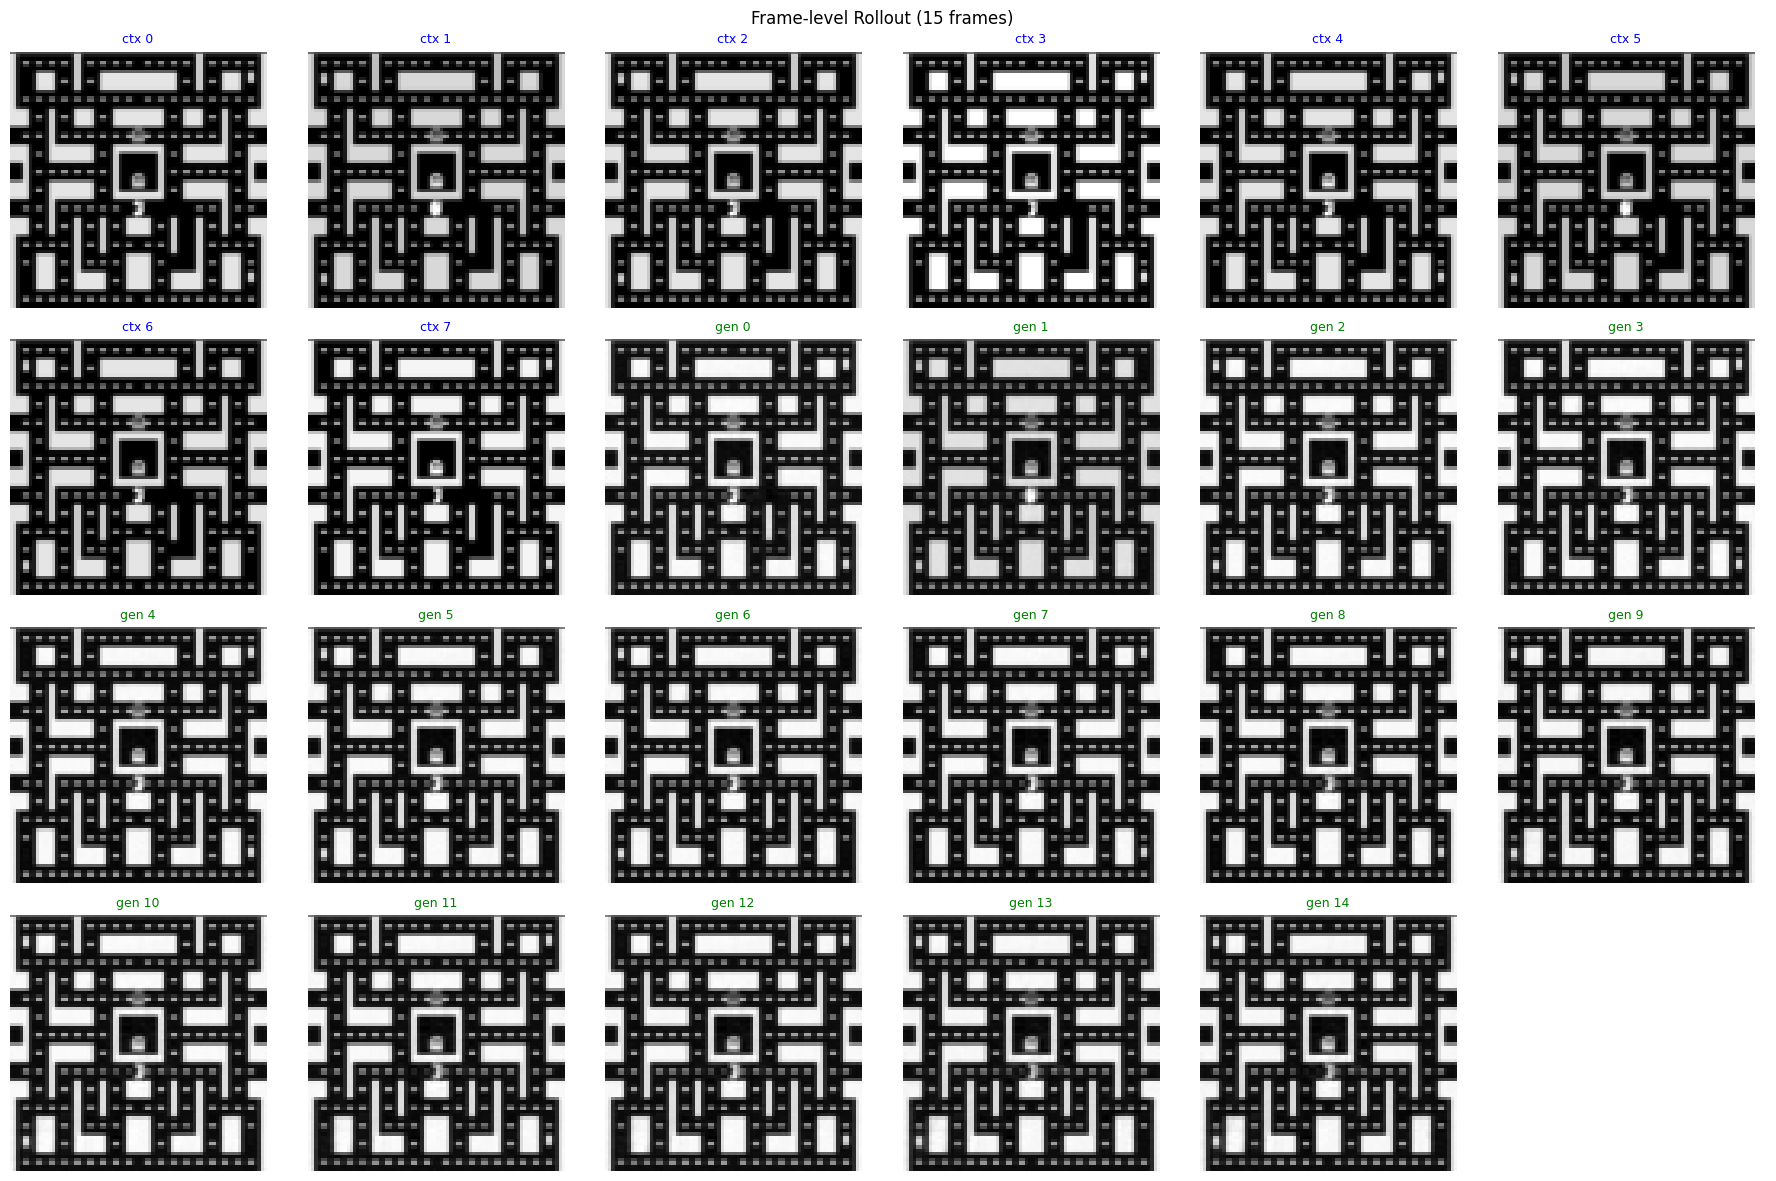

In [35]:
# Load the Frame-level Prior and autoregressively generate 15 frames by predicting
# entire latent feature maps, which are then quantised and decoded to pixel space.
frame_prior = FrameLevelPrior(
    latent_channels=64, latent_h=10, latent_w=10,
    d_model=256, nhead=8, num_layers=4, dropout=0.1
).to(device)

ckpt_path = FRAME_PRIOR_PATH_OUTPUT if os.path.exists(FRAME_PRIOR_PATH_OUTPUT) else FRAME_PRIOR_PATH_INPUT
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    frame_prior.load_state_dict(ckpt['model_state_dict'])
    frame_prior.eval()
    print(f"Frame Prior loaded from {ckpt_path}")

# Build the frame-prior test loader with 8-frame context and 1-frame prediction target.
_, test_fp_loader = build_loaders_frame_prior(
    raw_frames_50k, seq_len=8, target_len=1, batch_size=16, split_seed=42
)

# Encode context frames into latent space and roll out new frames autoregressively.
NUM_FRAMES_GENERATE = 15
sample_ctx, _ = next(iter(test_fp_loader))
context = sample_ctx[0:1].to(device)

with torch.no_grad():
    B, T, C, H, W = context.shape
    ctx_flat  = context.view(B * T, C, H, W)
    z_history = vqvae_original.encoder(ctx_flat).view(B, T, 64, 10, 10)
    visual_frames = [context[0, f].cpu().squeeze() for f in range(T)]

    print(f"Generating {NUM_FRAMES_GENERATE} frames frame-by-frame...")
    for step in tqdm(range(NUM_FRAMES_GENERATE)):
        z_next              = frame_prior(z_history)
        z_quantized, _      = vqvae_original.vq(z_next)
        gen_img             = vqvae_original.decoder(z_quantized).detach().cpu().squeeze()
        visual_frames.append(gen_img)
        # Append the new latent frame and maintain a fixed-length context window.
        z_next_exp = z_next.unsqueeze(1)
        z_history  = torch.cat([z_history, z_next_exp], dim=1)
        if z_history.shape[1] > T:
            z_history = z_history[:, -T:]

# Display context frames (blue) and generated frames (green) in a grid layout.
total = len(visual_frames)
cols  = 6
rows  = (total + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).flatten()

for i, img in enumerate(visual_frames):
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    if i < T:
        axes[i].set_title(f'ctx {i}',   color='blue',  fontsize=9)
    else:
        axes[i].set_title(f'gen {i-T}', color='green', fontsize=9)

for j in range(total, len(axes)):
    axes[j].axis('off')

plt.suptitle('Frame-level Rollout (15 frames)', fontsize=12)
plt.tight_layout()
plt.show()

## 36. Export frame-level rollout as GIF

Same normalisation and assembly pipeline as Section 31. Frame duration set to 300 ms (vs. 400 ms for the token-level GIF) to reflect the smoother, more temporally coherent output.

In [36]:
# Convert the frame-level rollout tensors to uint8 PIL images and save as an animated GIF.
from PIL import Image
import numpy as np

print("Creating frame-level GIF...")
gif_frames_pil = []
for img_tensor in visual_frames:
    img_np = img_tensor.numpy()
    # Normalise pixel values to [0, 255] before conversion.
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8) * 255.0
    gif_frames_pil.append(Image.fromarray(img_np.astype(np.uint8)))

gif_frames_pil[0].save(
    GIF_FRAME_PATH, save_all=True,
    append_images=gif_frames_pil[1:], duration=300, loop=0
)
print(f"✅ GIF saved to: {GIF_FRAME_PATH}")

Creating frame-level GIF...
✅ GIF saved to: /kaggle/working/pacman_dream_framelevel.gif


## 37. Frame Prior training curves

Applies `plot_training_history` to the Frame Prior checkpoint. Expected: MSE loss decreasing monotonically over 30 epochs on the 50k corpus, with no divergence — a stable curve confirms the Transformer learned frame-to-frame latent transitions without exposure bias compounding.

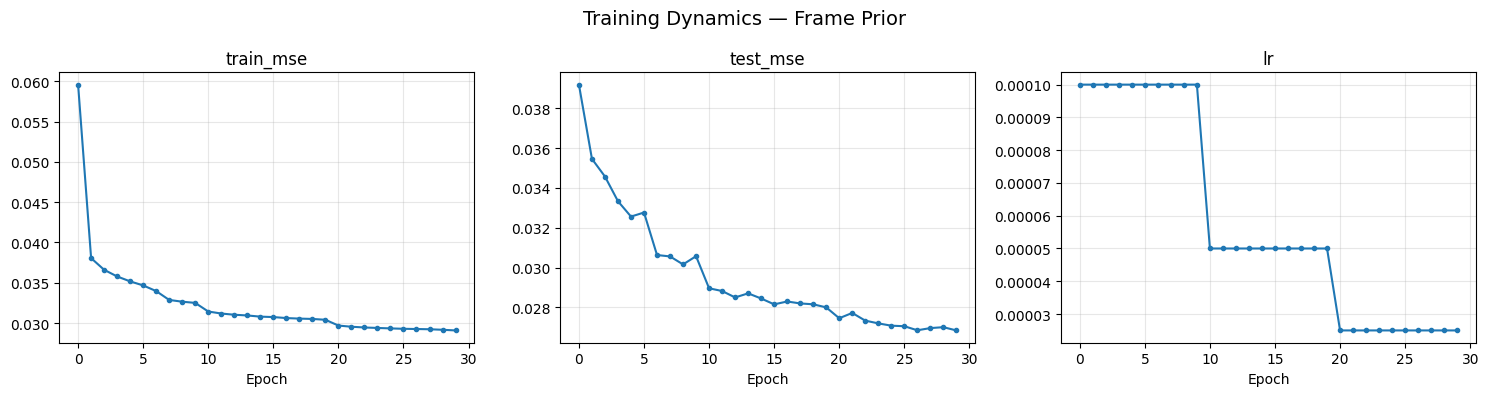

In [37]:
# Plot Frame Prior history
fp_ckpt = FRAME_PRIOR_PATH_OUTPUT if os.path.exists(FRAME_PRIOR_PATH_OUTPUT) else FRAME_PRIOR_PATH_INPUT
plot_training_history(fp_ckpt, "Training Dynamics — Frame Prior")

## 38. Token-level vs. frame-level rollout comparison

Side-by-side comparison of both priors on the same 15-frame horizon.

- **Token Prior**: 100 forward passes per frame; error compounds across the 10×10 token grid — geometric drift visible after 1–2 frames.
- **Frame Prior**: 1 forward pass per frame; maze structure preserved for 15+ steps but moving entities fade due to MSE regression-to-the-mean.

The efficiency gap is ~100× in inference cost (O(S×100) vs. O(S) forward passes), making the Frame Prior the practical choice for real-time world simulation.

  QUALITATIVE COMPARISON: Token-level vs Frame-level  
Token-level GIF: /kaggle/working/pacman_dream.gif
Frame-level GIF: /kaggle/working/pacman_dream_framelevel.gif



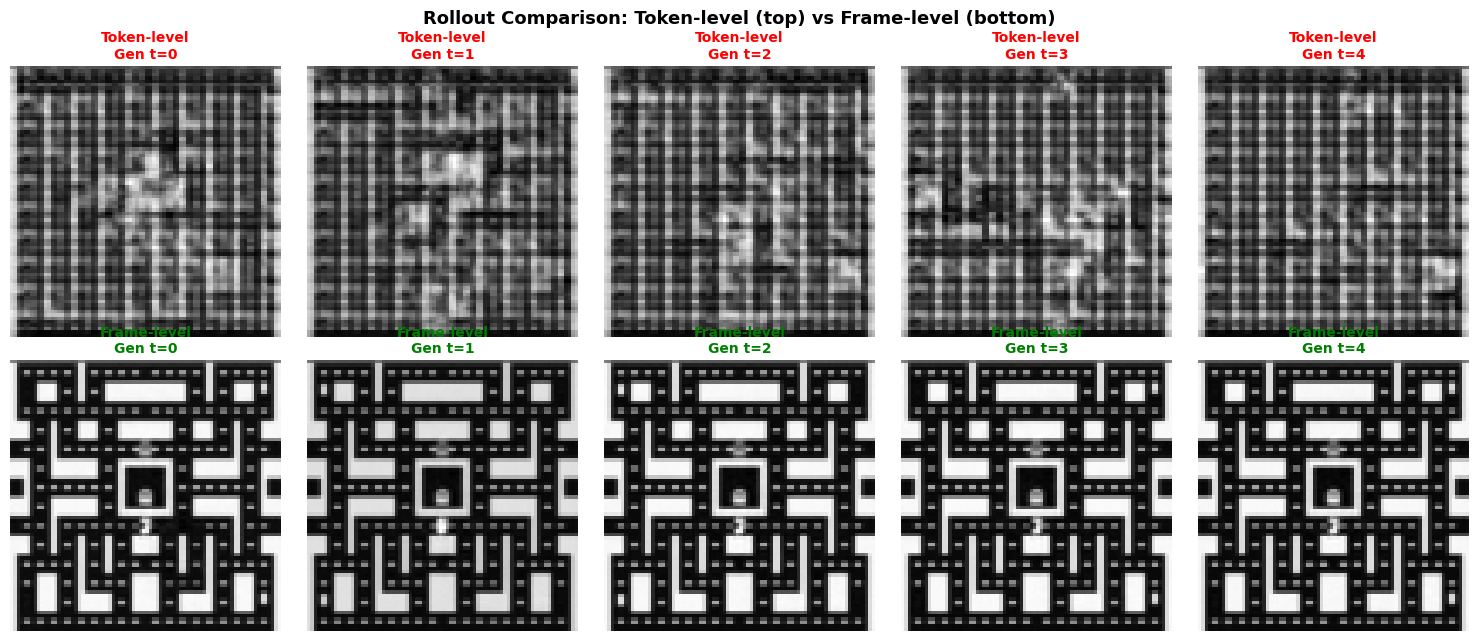


Observations:
- Token-level: degrades into structured noise after 1-2 frames (error accumulation).
- Frame-level: preserves maze structure throughout all generated frames.
- Speed: Frame-level is ~100x faster (1 step vs 100 steps per frame).


In [38]:
# Qualitative comparison of token-level and frame-level rollouts by extracting
# generated frames from both GIFs and displaying them side by side.
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

print("="*60)
print("  QUALITATIVE COMPARISON: Token-level vs Frame-level  ")
print("="*60)

N_COMPARE = 8

# Resolve the token-level GIF path, preferring the current session output.
gif_token_path = None
if os.path.exists(GIF_OUTPUT_PATH):
    gif_token_path = GIF_OUTPUT_PATH
    print(f"Token-level GIF: {GIF_OUTPUT_PATH}")
elif 'GIF_TOKEN_INPUT' in dir() and os.path.exists(GIF_TOKEN_INPUT):
    gif_token_path = GIF_TOKEN_INPUT
    print(f"Token-level GIF (pre-trained): {GIF_TOKEN_INPUT}")

# Resolve the frame-level GIF path.
gif_frame_path = None
if os.path.exists(GIF_FRAME_PATH):
    gif_frame_path = GIF_FRAME_PATH
    print(f"Frame-level GIF: {GIF_FRAME_PATH}")
elif 'GIF_FRAME_INPUT' in dir() and os.path.exists(GIF_FRAME_INPUT):
    gif_frame_path = GIF_FRAME_INPUT
    print(f"Frame-level GIF (pre-trained): {GIF_FRAME_INPUT}")

print()

if gif_token_path is None or gif_frame_path is None:
    print("⚠️ GIF files missing. Run the token-level and frame-level rollout cells first.")
else:
    gif_token = Image.open(gif_token_path)
    gif_frame = Image.open(gif_frame_path)

    # Skip context frames and extract only the generated portion of each GIF.
    SKIP_CONTEXT = 8

    token_frames = []
    try:
        for i in range(SKIP_CONTEXT, SKIP_CONTEXT + N_COMPARE):
            gif_token.seek(i)
            token_frames.append(gif_token.copy().convert('L'))
    except EOFError:
        pass

    frame_frames = []
    try:
        for i in range(SKIP_CONTEXT, SKIP_CONTEXT + N_COMPARE):
            gif_frame.seek(i)
            frame_frames.append(gif_frame.copy().convert('L'))
    except EOFError:
        pass

    n_show = min(len(token_frames), len(frame_frames), N_COMPARE)

    if n_show == 0:
        print("⚠️ No frames available for comparison.")
    else:
        fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6.5))

        for i in range(n_show):
            axes[0, i].imshow(np.array(token_frames[i]), cmap='gray')
            axes[0, i].axis('off')
            axes[0, i].set_title(f"Token-level\nGen t={i}", fontsize=10, color='red',   fontweight='bold')

            axes[1, i].imshow(np.array(frame_frames[i]), cmap='gray')
            axes[1, i].axis('off')
            axes[1, i].set_title(f"Frame-level\nGen t={i}", fontsize=10, color='green', fontweight='bold')

        plt.suptitle(
            "Rollout Comparison: Token-level (top) vs Frame-level (bottom)",
            fontsize=13, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

        print("\nObservations:")
        print("- Token-level: degrades into structured noise after 1-2 frames (error accumulation).")
        print("- Frame-level: preserves maze structure throughout all generated frames.")
        print("- Speed: Frame-level is ~100x faster (1 step vs 100 steps per frame).")

## 40. Multi-seed evaluation (seeds 7, 42, 123)

Runs `aggregate_multiseed.py` to evaluate Baseline, VQ-VAE, and Temporal Transformer across 3 seeds and report mean ± std. Confirms that the accuracy gains reported in Section 39 are not attributable to a favourable single initialisation.

In [39]:

%cd /kaggle/working/pacman-world-model

!python train_baseline_multiseed.py training.seed=42
!python train_baseline_multiseed.py training.seed=123
!python train_baseline_multiseed.py training.seed=7



!python train_vqvae_multiseed.py model=vqvae training.seed=42
!python train_vqvae_multiseed.py model=vqvae training.seed=123
!python train_vqvae_multiseed.py model=vqvae training.seed=7


!python train_transformer_multiseed.py model=transformer_classifier training.seed=42
!python train_transformer_multiseed.py model=transformer_classifier training.seed=123
!python train_transformer_multiseed.py model=transformer_classifier training.seed=7

/kaggle/working/pacman-world-model

Multi-seed Baseline training -- SEED=42

Loading cached dataset from data/raw_frames_10k.npz...
Class weight DANGER: 15.29
Training on cuda...
Ep [1/10]: 100%|██████████████████████████████| 250/250 [00:07<00:00, 34.01it/s]
  Ep 1: loss=1.3125
Ep [2/10]: 100%|██████████████████████████████| 250/250 [00:06<00:00, 36.58it/s]
  Ep 2: loss=0.7169
Ep [3/10]: 100%|██████████████████████████████| 250/250 [00:06<00:00, 36.33it/s]
  Ep 3: loss=0.4172
Ep [4/10]: 100%|██████████████████████████████| 250/250 [00:06<00:00, 35.95it/s]
  Ep 4: loss=0.3379
Ep [5/10]: 100%|██████████████████████████████| 250/250 [00:07<00:00, 35.65it/s]
  Ep 5: loss=0.3260
Ep [6/10]: 100%|██████████████████████████████| 250/250 [00:06<00:00, 35.76it/s]
  Ep 6: loss=0.2607
Ep [7/10]: 100%|██████████████████████████████| 250/250 [00:06<00:00, 36.21it/s]
  Ep 7: loss=0.2205
Ep [8/10]: 100%|██████████████████████████████| 250/250 [00:06<00:00, 36.62it/s]
  Ep 8: loss=0.2315
Ep [9/10]: 10

In [40]:
# ── Pruning multi-seed evaluation ──────────────────────────────────────────
!python evaluate_pruning_multiseed.py

# ── Re-run aggregation (ora include anche vqvae_pruned) ────────────────────
!python aggregate_multiseed.py

Device : cuda
Seeds  : [7, 42, 123]
Pruning: 20% unstructured L1

Loading cached dataset from data/raw_frames_10k.npz...
SEED = 7
  Unpruned — acc=96.2000%  F1=0.7532
  Global sparsity: 20.00%
    0                             : 19.9%
    4                             : 20.0%
    7                             : 20.0%
    10                            : 20.0%
  Pruned   — acc=95.7000%  F1=0.7278  Δacc=-0.5000%

  Saved: checkpoints/vqvae_pruned_seed7_metrics.json
SEED = 42
  Unpruned — acc=96.0500%  F1=0.7539
  Global sparsity: 20.00%
    0                             : 19.9%
    4                             : 20.0%
    7                             : 20.0%
    10                            : 20.0%
  Pruned   — acc=96.8500%  F1=0.7893  Δacc=+0.8000%

  Saved: checkpoints/vqvae_pruned_seed42_metrics.json
SEED = 123
  Unpruned — acc=96.5000%  F1=0.7697
  Global sparsity: 20.00%
    0                             : 19.9%
    4                             : 20.0%
    7                      

## 41. Quantitative rollout evaluation — PSNR over 15 steps

Runs `rollout_psnr.py` across 50 unseen contexts, measuring PSNR between generated and ground-truth frames at each of 15 autoregressive steps for both priors.

Expected: token prior collapses to 14.33 ± 0.12 dB at step 1; frame prior stabilises at 30.79 ± 2.98 dB after 15 steps. Quantifies the qualitative observations from Section 38.

In [41]:

!python rollout_psnr.py

Device: cuda
Loading VQ-VAE...
Loading Token Prior...
Loading Frame Prior...
Loading frames from /kaggle/input/datasets/leonardocostantini02/dataseets/raw_frames_50k.npz...
Loading cached dataset from /kaggle/input/datasets/leonardocostantini02/dataseets/raw_frames_50k.npz...
  [10/50] done. Token PSNR(t=1): 14.25  Frame PSNR(t=1): 31.89
  [20/50] done. Token PSNR(t=1): 14.58  Frame PSNR(t=1): 34.58
  [30/50] done. Token PSNR(t=1): 14.44  Frame PSNR(t=1): 31.85
  [40/50] done. Token PSNR(t=1): 14.17  Frame PSNR(t=1): 30.52
  [50/50] done. Token PSNR(t=1): 14.37  Frame PSNR(t=1): 38.58

PSNR (dB) vs rollout step, averaged over 50 contexts
step |     Token mean ± std |     Frame mean ± std
----------------------------------------------------------------------
   1 |      14.33 ±  0.12    |      34.20 ±  5.48
   2 |      14.34 ±  0.15    |      33.27 ±  4.79
   3 |      14.42 ±  0.16    |      32.85 ±  4.27
   4 |      14.44 ±  0.14    |      32.72 ±  4.86
   5 |      14.47 ±  0.08    |  

## 39. Results summary

| Model | Input | Accuracy (%) | F1 (DANGER) |
| :--- | :--- | :--- | :--- |
| Baseline (continuous) | 1 frame | 92.02 ± 1.13 | 0.60 ± 0.03 |
| VQ-VAE (discrete) | 1 frame | 96.25 ± 0.23 | 0.76 ± 0.01 |
| **Temporal Transformer** | **8 frames** | **98.32 ± 0.78** | **0.87 ± 0.06** |
| VQ-VAE + 20% L1 pruning | 1 frame | 96.38 ± 0.60 | 0.76 ± 0.03 |

**Generative rollouts** — token prior stabilises at 14.33 ± 0.12 dB PSNR at step 1; frame prior holds at 30.79 ± 2.98 dB after 15 steps.

To reproduce all results from scratch, run the training scripts in dependency order:

```bash
python train_baseline.py
python train_vqvae.py
python train_transformer.py
python train_token_prior.py
python train_frame_prior.py dataset=pacman_50k
```